1st Deliverable EDA

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np


In [2]:
airports_df = pd.read_csv('./Dataset/Airports Data.csv')
flight_df = pd.read_csv('./Dataset/Flight Level Data.csv')
pnr_flight_df = pd.read_csv('./Dataset/PNR+Flight+Level+Data.csv')
pnr_remark_df = pd.read_csv('./Dataset/PNR Remark Level Data.csv')
bag_df = pd.read_csv('./Dataset/Bag+Level+Data.csv')

Shape of Dataset

In [3]:
print("Flight Data:", flight_df.shape)
print("PNR Flight Data:", pnr_flight_df.shape)
print("PNR Remark Data:", pnr_remark_df.shape)
print("Bag Data:", bag_df.shape)
print("Airport Data:", airports_df.shape)

Flight Data: (8099, 15)
PNR Flight Data: (687878, 12)
PNR Remark Data: (51698, 4)
Bag Data: (687245, 8)
Airport Data: (5612, 2)


What is the average delay and what percentage of flights depart later than scheduled?

Convert datetime

In [4]:
flight_df['actual_departure_datetime_local'] = pd.to_datetime(flight_df['actual_departure_datetime_local'], errors='coerce')
flight_df['scheduled_departure_datetime_local'] = pd.to_datetime(flight_df['scheduled_departure_datetime_local'], errors='coerce')

Delay Calculations

In [5]:
flight_df['delay_minutes'] = (flight_df['actual_departure_datetime_local'] - flight_df['scheduled_departure_datetime_local']).dt.total_seconds() / 60
avg_delay = flight_df['delay_minutes'].mean()
pct_late = (flight_df['delay_minutes'] > 0).mean() * 100
print(f'Average delay: {avg_delay:.2f} minutes')
print(f'Percentage of flights departing late: {pct_late:.2f}%')

Average delay: 21.18 minutes
Percentage of flights departing late: 49.61%


Plots of Delay

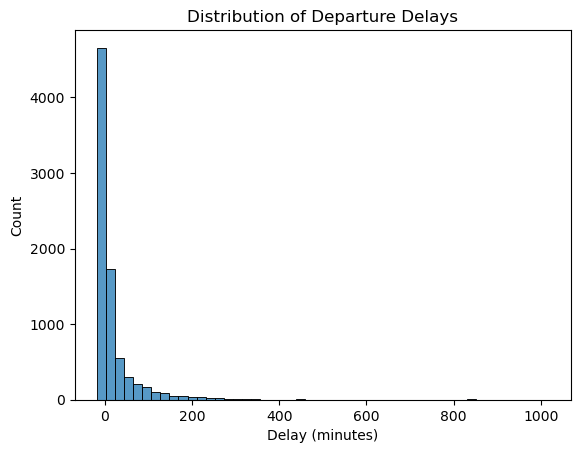

In [6]:
sns.histplot(flight_df['delay_minutes'], bins=50)
plt.title('Distribution of Departure Delays')
plt.xlabel('Delay (minutes)')
plt.ylabel('Count')
plt.savefig('./Output_Images/delay_distribution.png')
plt.show()

How many flights have scheduled ground time close to or below the minimum turn mins?

Calculation

In [7]:
flight_df['ground_time_ratio'] = flight_df['scheduled_ground_time_minutes'] / flight_df['minimum_turn_minutes']
flight_df['is_tight_ground'] = (flight_df['scheduled_ground_time_minutes'] <= flight_df['minimum_turn_minutes'] * 1.1).astype(int)
tight_ground_pct = flight_df['is_tight_ground'].mean() * 100
tight_ground_count = flight_df['is_tight_ground']
# Count how many flights are tight
tight_ground_count = flight_df['is_tight_ground'].sum()

# Total flights
total_flights = len(flight_df)

# Print results
print(f"Total flights analyzed: {total_flights}")
print(f"Tight ground flights: {tight_ground_count}")

Total flights analyzed: 8099
Tight ground flights: 780


Percentage of flights with tight ground time: 9.63%
Flights that have scheduled ground time close to or below the minimum turn mins: 780


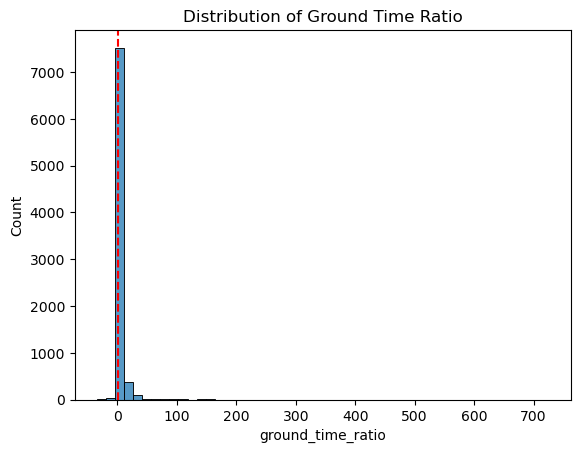

In [8]:
print(f'Percentage of flights with tight ground time: {tight_ground_pct:.2f}%')
print(f'Flights that have scheduled ground time close to or below the minimum turn mins: {tight_ground_count}')
sns.histplot(flight_df['ground_time_ratio'], bins=50)
plt.axvline(1.1, color='red', linestyle='--', label='Tight Ground Threshold')
plt.title('Distribution of Ground Time Ratio')
plt.savefig('ground_time_ratio.png')

The average ratio of transfer bags vs. checked bags across flights

In [9]:
import pandas as pd

# Step 1: Clean column names if necessary (optional but safe)
bag_df.columns = bag_df.columns.str.strip().str.lower()

# Step 2: Create route identifier (optional, for easier visualization)
bag_df['route'] = bag_df['scheduled_departure_station_code'] + "_" + bag_df['scheduled_arrival_station_code']

# Step 3: Aggregate counts by route
bag_summary = (
    bag_df.groupby(['scheduled_departure_station_code', 'scheduled_arrival_station_code', 'bag_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Step 4: Rename columns for clarity
bag_summary = bag_summary.rename(columns={
    'Transfer': 'transfer_bag_count',
    'Checked': 'origin_bag_count',
    'Hot Transfer': 'hot_transfer_bag_count'
})

# Step 5: Ensure missing columns exist (in case a bag_type wasn’t present in data)
for col in ['transfer_bag_count', 'origin_bag_count', 'hot_transfer_bag_count']:
    if col not in bag_summary.columns:
        bag_summary[col] = 0

# Step 6: Preview the results
bag_summary


bag_type,scheduled_departure_station_code,scheduled_arrival_station_code,hot_transfer_bag_count,Origin,transfer_bag_count,origin_bag_count
0,ORD,ABE,78,283,472,0
1,ORD,ABQ,299,743,1348,0
2,ORD,ABV,0,0,2,0
3,ORD,ACC,0,0,5,0
4,ORD,ACK,35,231,18,0
...,...,...,...,...,...,...
357,ORD,YYC,198,1340,1045,0
358,ORD,YYZ,676,3087,3258,0
359,ORD,ZAG,0,0,2,0
360,ORD,ZRH,119,1141,3846,0


In [10]:
bag_summary = bag_summary.drop(columns=['origin_bag_count'])


In [11]:
bag_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   scheduled_departure_station_code  362 non-null    object
 1   scheduled_arrival_station_code    362 non-null    object
 2   hot_transfer_bag_count            362 non-null    int64 
 3   Origin                            362 non-null    int64 
 4   transfer_bag_count                362 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 14.3+ KB


In [12]:
bag_summary.head()

bag_type,scheduled_departure_station_code,scheduled_arrival_station_code,hot_transfer_bag_count,Origin,transfer_bag_count
0,ORD,ABE,78,283,472
1,ORD,ABQ,299,743,1348
2,ORD,ABV,0,0,2
3,ORD,ACC,0,0,5
4,ORD,ACK,35,231,18


In [13]:
bag_summary['ratio_trans_origin'] = bag_summary['transfer_bag_count'] / bag_summary['Origin'].replace(0, pd.NA)
bag_summary['ratio_trans_origin'] = bag_summary['ratio_trans_origin'].fillna(0)


In [14]:
avg_ratio_trans_origin = bag_summary['ratio_trans_origin'].mean()
print(f"Average ratio of transfer to origin bags: {avg_ratio_trans_origin:.2f}")


Average ratio of transfer to origin bags: 7.16


Create route identifier

Dropping flight_number

In [15]:
# Aggregate PNR-level passengers to flight-level
pax_summary = (
    pnr_flight_df
    .groupby(['flight_number','scheduled_departure_date_local',
              'scheduled_departure_station_code','scheduled_arrival_station_code'], as_index=False)
    .agg(total_pax=('total_pax','sum'))
)

In [16]:
flight_with_pax = flight_df.merge(
    pax_summary,
    on=['flight_number','scheduled_departure_date_local',
        'scheduled_departure_station_code','scheduled_arrival_station_code'],
    how='left'
)

In [17]:
flight_with_pax['load_factor'] = flight_with_pax['total_pax'] / flight_with_pax['total_seats']

In [18]:
flight_with_pax.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,fleet_type,carrier,scheduled_ground_time_minutes,actual_ground_time_minutes,minimum_turn_minutes,delay_minutes,ground_time_ratio,is_tight_ground,total_pax,load_factor
0,OO,4792,2025-08-04,ORD,ROA,2025-08-04 17:57:00+00:00,2025-08-04T21:04:00Z,2025-08-04 18:04:00+00:00,2025-08-04T20:52:00Z,76,ERJ-175,Express,42,34,34,7.0,1.235294,0,65,0.855263
1,UA,920,2025-08-03,ORD,LHR,2025-08-03 18:05:00+00:00,2025-08-04T08:20:00Z,2025-08-03 18:27:00+00:00,2025-08-04T08:06:00Z,167,B767-300,Mainline,235,229,145,22.0,1.620690,0,171,1.023952
2,UA,1776,2025-08-10,ORD,PHL,2025-08-10 18:20:00+00:00,2025-08-10T21:35:00Z,2025-08-10 20:11:00+00:00,2025-08-10T23:26:00Z,166,B737-800,Mainline,76,69,51,111.0,1.490196,0,180,1.084337
3,OO,5790,2025-08-06,ORD,CRW,2025-08-06 18:20:00+00:00,2025-08-06T21:04:00Z,2025-08-06 20:05:00+00:00,2025-08-06T22:42:00Z,50,CRJ-200,Express,223,38,29,105.0,7.689655,0,55,1.100000
4,UA,1398,2025-08-05,ORD,ATL,2025-08-05 18:20:00+00:00,2025-08-05T21:29:00Z,2025-08-05 18:16:00+00:00,2025-08-05T21:49:00Z,166,B737-800,Mainline,75,72,51,-4.0,1.470588,0,136,0.819277


In [19]:
flight_with_pax['delay_min'] = (
    pd.to_datetime(flight_with_pax['actual_departure_datetime_local']) -
    pd.to_datetime(flight_with_pax['scheduled_departure_datetime_local'])
).dt.total_seconds() / 60

flight_with_pax['late_flag'] = flight_with_pax['delay_min'] > 15

In [20]:
# Correlation
corr = flight_with_pax[['load_factor','delay_min']].corr(method='spearman')

import statsmodels.api as sm
X_data = sm.add_constant(flight_with_pax[['load_factor']])
y_data = flight_with_pax['late_flag'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

# 2c. Add the constant (intercept) term to the predictor variables
# This is required by statsmodels to properly fit the regression line.
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

print("\n--- Model Training Status ---")
print(f"Training Logistic Regression model on {len(X_train)} samples...")

# 3. Model Training (Fitting the Logit model)
# sm.Logit specifies Logistic Regression. The.fit() command performs the training.
model = sm.Logit(y_train, X_train_const).fit()

model.summary()


--- Model Training Status ---
Training Logistic Regression model on 6479 samples...
Optimization terminated successfully.
         Current function value: 0.574870
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              late_flag   No. Observations:                 6479
Model:                          Logit   Df Residuals:                     6477
Method:                           MLE   Df Model:                            1
Date:                Sun, 05 Oct 2025   Pseudo R-squ.:                0.002816
Time:                        19:07:15   Log-Likelihood:                -3724.6
converged:                       True   LL-Null:                       -3735.1
Covariance Type:            nonrobust   LLR p-value:                 4.513e-06
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4047      0.138     -2.943      0.003      -0.674      -0.135
load_factor    -0.6128      0.133     -4.610      0.000      -0.873      -0.352
===============================================================================
"""

In [21]:

# Generate predictions on the test set
# Predicts the probability (P) of the flight being 'Difficult' (late_flag = 1)
test_probabilities = model.predict(X_test_const)

# Create a final 'Difficulty Score' (FDS) using the predicted probability
# The FDS is a continuous score from 0 to 1, representing the likelihood of delay
df_predictions = X_test.copy()
df_predictions = test_probabilities

# Define Classification Thresholds based on operational risk tolerance [2]
# Note: These thresholds should be empirically adjusted based on cost of delay [3]
THRESHOLD_DIFFICULT = 0.80  # 80% or greater chance of being late
THRESHOLD_MEDIUM = 0.40     # 40% to 80% chance of being late

def assign_classification(prob):
    if prob >= THRESHOLD_DIFFICULT:
        return 'Difficult'
    elif prob >= THRESHOLD_MEDIUM:
        return 'Medium'
    else:
        return 'Easy'

# Apply classification to the predictions
df_predictions = df_predictions.apply(assign_classification)


# --- 6. Model Evaluation (For Hackathon Validation) ----------------------
# Evaluate the model's predictive power
auc_score = roc_auc_score(y_test, test_probabilities)
print(f"\nModel Performance (AUC Score): {auc_score:.4f}")


Model Performance (AUC Score): 0.5048


In [22]:
flight_with_pax['delay_min'] = (
    pd.to_datetime(flight_with_pax['actual_departure_datetime_local']) -
    pd.to_datetime(flight_with_pax['scheduled_departure_datetime_local'])
).dt.total_seconds() / 60

flight_with_pax['late_flag'] = flight_with_pax['delay_min'] > 15

In [23]:
flight_with_pax.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,...,scheduled_ground_time_minutes,actual_ground_time_minutes,minimum_turn_minutes,delay_minutes,ground_time_ratio,is_tight_ground,total_pax,load_factor,delay_min,late_flag
0,OO,4792,2025-08-04,ORD,ROA,2025-08-04 17:57:00+00:00,2025-08-04T21:04:00Z,2025-08-04 18:04:00+00:00,2025-08-04T20:52:00Z,76,...,42,34,34,7.0,1.235294,0,65,0.855263,7.0,False
1,UA,920,2025-08-03,ORD,LHR,2025-08-03 18:05:00+00:00,2025-08-04T08:20:00Z,2025-08-03 18:27:00+00:00,2025-08-04T08:06:00Z,167,...,235,229,145,22.0,1.620690,0,171,1.023952,22.0,True
2,UA,1776,2025-08-10,ORD,PHL,2025-08-10 18:20:00+00:00,2025-08-10T21:35:00Z,2025-08-10 20:11:00+00:00,2025-08-10T23:26:00Z,166,...,76,69,51,111.0,1.490196,0,180,1.084337,111.0,True
3,OO,5790,2025-08-06,ORD,CRW,2025-08-06 18:20:00+00:00,2025-08-06T21:04:00Z,2025-08-06 20:05:00+00:00,2025-08-06T22:42:00Z,50,...,223,38,29,105.0,7.689655,0,55,1.100000,105.0,True
4,UA,1398,2025-08-05,ORD,ATL,2025-08-05 18:20:00+00:00,2025-08-05T21:29:00Z,2025-08-05 18:16:00+00:00,2025-08-05T21:49:00Z,166,...,75,72,51,-4.0,1.470588,0,136,0.819277,-4.0,False


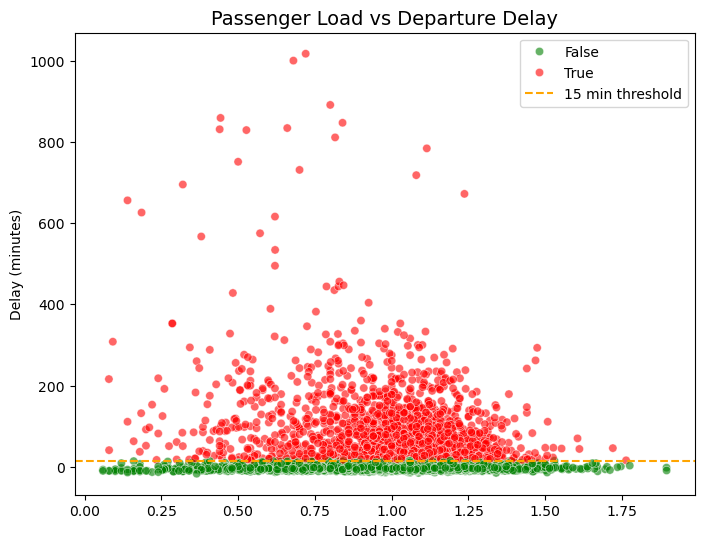

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    
    data=flight_with_pax,
    x='load_factor',
    y='delay_min',
    hue='late_flag',
    palette={True:"red", False:"green"},
    alpha=0.6
)
plt.axhline(15, color='orange', linestyle='--', label="15 min threshold")
plt.title("Passenger Load vs Departure Delay", fontsize=14)
plt.xlabel("Load Factor")
plt.ylabel("Delay (minutes)")
plt.legend()
plt.show()

C:\Users\SOURAV\AppData\Local\Temp\ipykernel_26328\444744844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flight_with_pax, x='load_group', y='delay_min', palette="Set2")


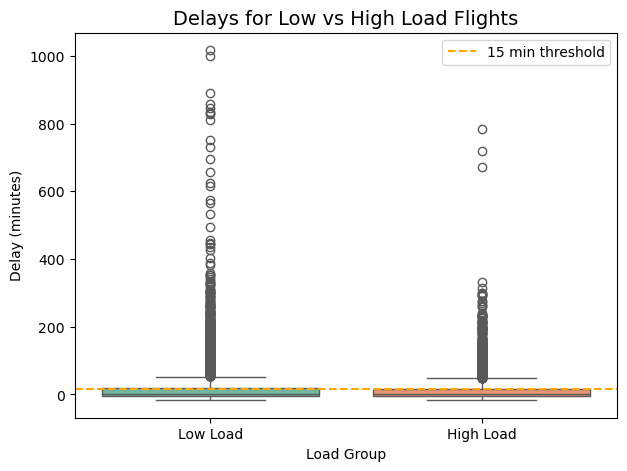

In [25]:
median_load = flight_with_pax['load_factor'].median()
flight_with_pax['load_group'] = np.where(flight_with_pax['load_factor'] >= median_load, "High Load", "Low Load")

plt.figure(figsize=(7,5))
sns.boxplot(data=flight_with_pax, x='load_group', y='delay_min', palette="Set2")
plt.axhline(15, color='orange', linestyle='--', label="15 min threshold")
plt.title("Delays for Low vs High Load Flights", fontsize=14)
plt.xlabel("Load Group")
plt.ylabel("Delay (minutes)")
plt.legend()
plt.show()

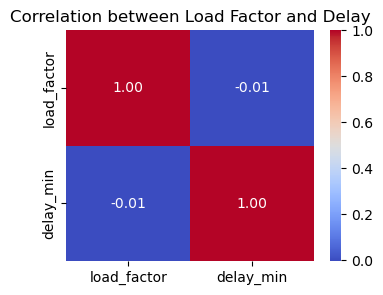

In [26]:
plt.figure(figsize=(4,3))
sns.heatmap(flight_with_pax[['load_factor','delay_min']].corr(method='spearman'),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Load Factor and Delay")
plt.show()

SSR and load factor


In [27]:
# 2a. Aggregate total passengers per flight
pax_summary = (
    pnr_flight_df
    .groupby(['flight_number','scheduled_departure_date_local',
              'scheduled_departure_station_code','scheduled_arrival_station_code'], as_index=False)
    .agg(total_pax=('total_pax','sum'))
)

In [28]:
# 2b. Merge SSRs with flight identifiers from pnr_flight_df
pnr_remark_df = pnr_remark_df.merge(
    pnr_flight_df[[
        'record_locator', 'flight_number', 'scheduled_departure_date_local',
        'scheduled_departure_station_code', 'scheduled_arrival_station_code'
    ]].drop_duplicates(),
    on=['record_locator','flight_number'],
    how='left'
)

In [29]:
# 2c. Aggregate SSR count per flight
ssr_summary = (
    pnr_remark_df
    .groupby(['flight_number','scheduled_departure_date_local',
              'scheduled_departure_station_code','scheduled_arrival_station_code'], as_index=False)
    .agg(special_requests_count=('special_service_request','count'))
)


In [30]:
# 2d. Merge passenger load and SSR count into flight_df
flight_with_pax = flight_df.merge(
    pax_summary,
    on=['flight_number','scheduled_departure_date_local',
        'scheduled_departure_station_code','scheduled_arrival_station_code'],
    how='left'
)

flight_with_pax = flight_with_pax.merge(
    ssr_summary,
    on=['flight_number','scheduled_departure_date_local',
        'scheduled_departure_station_code','scheduled_arrival_station_code'],
    how='left'
)

In [31]:
# Fill missing values
flight_with_pax['total_pax'] = flight_with_pax['total_pax'].fillna(0)
flight_with_pax['special_requests_count'] = flight_with_pax['special_requests_count'].fillna(0)

In [32]:
# ================================================
# 3️⃣ Compute load factor and delay metrics
# ================================================
flight_with_pax['load_factor'] = flight_with_pax['total_pax'] / flight_with_pax['total_seats']

flight_with_pax['delay_min'] = (
    pd.to_datetime(flight_with_pax['actual_departure_datetime_local']) -
    pd.to_datetime(flight_with_pax['scheduled_departure_datetime_local'])
).dt.total_seconds() / 60

flight_with_pax['late_flag'] = (flight_with_pax['delay_min'] > 15).astype(int)

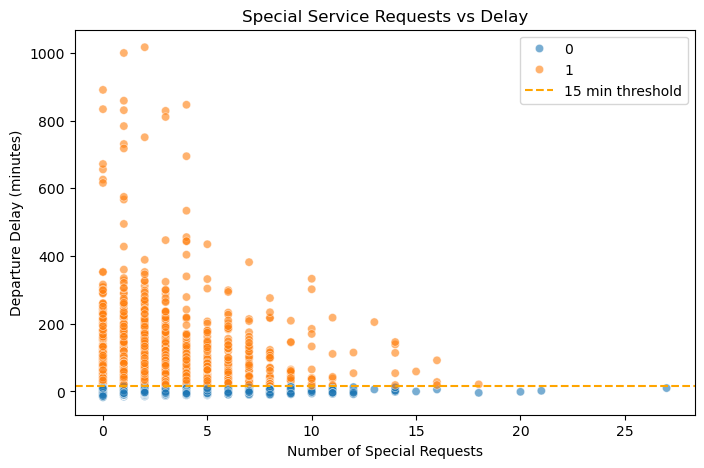

In [33]:
# ================================================
# 4️⃣ Exploratory plots
# ================================================
# Load vs Delay scatter
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=flight_with_pax,
    x='special_requests_count',
    y='delay_min',
    hue='late_flag',
    alpha=0.6
)
plt.axhline(15, color='orange', linestyle='--', label='15 min threshold')
plt.title("Special Service Requests vs Delay")
plt.xlabel("Number of Special Requests")
plt.ylabel("Departure Delay (minutes)")
plt.legend()
plt.show()


C:\Users\SOURAV\AppData\Local\Temp\ipykernel_26328\4055986787.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flight_with_pax, x='ssr_group', y='delay_min', palette="Set2")


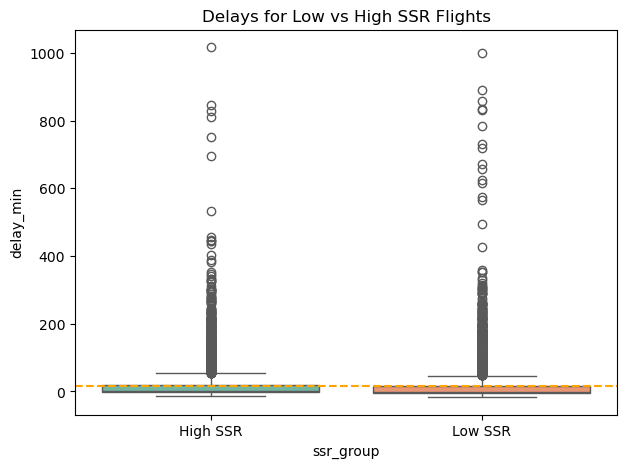

In [34]:
# Boxplot: High vs Low SSR flights
median_ssr = flight_with_pax['special_requests_count'].median()
flight_with_pax['ssr_group'] = np.where(flight_with_pax['special_requests_count'] >= median_ssr, "High SSR", "Low SSR")

plt.figure(figsize=(7,5))
sns.boxplot(data=flight_with_pax, x='ssr_group', y='delay_min', palette="Set2")
plt.axhline(15, color='orange', linestyle='--')
plt.title("Delays for Low vs High SSR Flights")
plt.show()

In [35]:
# ================================================
# 5️⃣ Regression Analysis (controlling for passenger load)
# ================================================
# Linear regression (delay minutes)
X = flight_with_pax[['total_pax','special_requests_count']]
X = sm.add_constant(X)
y = flight_with_pax['delay_min']

ols_model = sm.OLS(y, X).fit()
print("=== Linear Regression: Delay vs Pax + SSR ===")
print(ols_model.summary())

# Logistic regression (late_flag)
y_bin = flight_with_pax['late_flag']
logit_model = sm.Logit(y_bin, X).fit()
print("=== Logistic Regression: Late Flag vs Pax + SSR ===")
print(logit_model.summary())



=== Linear Regression: Delay vs Pax + SSR ===
                            OLS Regression Results                            
Dep. Variable:              delay_min   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     11.41
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           1.13e-05
Time:                        19:07:19   Log-Likelihood:                -44928.
No. Observations:                8099   AIC:                         8.986e+04
Df Residuals:                    8096   BIC:                         8.988e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

Merging the code

In [36]:
# Put them in a dictionary with variable names as keys
all_dfs = {
    "airports_df": airports_df,
    "bag_level_df": bag_df,
    "flight_df": flight_df,
    "PNR_remark_df": pnr_remark_df,
    "PNR_fight_df": pnr_flight_df,
}

# Loop and print
for name, df in all_dfs.items():
    print(name, df.shape, df.columns.tolist(), np.sum(df.isnull()))

airports_df (5612, 2) ['airport_iata_code', 'iso_country_code'] airport_iata_code     0
iso_country_code     15
dtype: int64


d:\anaconda\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


bag_level_df (687245, 9) ['company_id', 'flight_number', 'scheduled_departure_date_local', 'scheduled_departure_station_code', 'scheduled_arrival_station_code', 'bag_tag_unique_number', 'bag_tag_issue_date', 'bag_type', 'route'] company_id                          0
flight_number                       0
scheduled_departure_date_local      0
scheduled_departure_station_code    0
scheduled_arrival_station_code      0
bag_tag_unique_number               0
bag_tag_issue_date                  0
bag_type                            0
route                               0
dtype: int64
flight_df (8099, 18) ['company_id', 'flight_number', 'scheduled_departure_date_local', 'scheduled_departure_station_code', 'scheduled_arrival_station_code', 'scheduled_departure_datetime_local', 'scheduled_arrival_datetime_local', 'actual_departure_datetime_local', 'actual_arrival_datetime_local', 'total_seats', 'fleet_type', 'carrier', 'scheduled_ground_time_minutes', 'actual_ground_time_minutes', 'minimum_turn_

In [37]:
pnr_merge_df = pd.merge(
    pnr_remark_df, 
    pnr_flight_df, 
    on=['record_locator', 'pnr_creation_date', 'flight_number'],
    how='inner'
)

In [38]:
pnr_merge_df


,record_locator,pnr_creation_date,flight_number,special_service_request,scheduled_departure_date_local_x,scheduled_departure_station_code_x,scheduled_arrival_station_code_x,company_id,scheduled_departure_date_local_y,scheduled_departure_station_code_y,scheduled_arrival_station_code_y,total_pax,is_child,basic_economy_ind,is_stroller_user,lap_child_count
0,PNR_153489,2025-07-04,2182,Airport Wheelchair,2025-08-04,ORD,PHL,UA,2025-08-04,ORD,PHL,2,N,0,N,0
1,PNR_153508,2025-07-10,2649,Airport Wheelchair,2025-08-08,ORD,EWR,UA,2025-08-08,ORD,EWR,1,N,1,N,0
2,PNR_153521,2025-03-01,970,Unaccompanied Minor,2025-08-10,ORD,FCO,UA,2025-08-10,ORD,FCO,1,N,0,N,0
3,PNR_153522,2025-07-15,5380,Airport Wheelchair,2025-08-08,ORD,MSY,OO,2025-08-08,ORD,MSY,2,N,0,N,0
4,PNR_153543,2025-03-07,5230,Airport Wheelchair,2025-08-13,ORD,CRW,OO,2025-08-13,ORD,CRW,1,N,1,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18159,PNR_610579,2025-05-19,1328,Unaccompanied Minor,2025-08-07,ORD,SMF,UA,2025-08-07,ORD,SMF,1,N,0,N,0
18160,PNR_610587,2025-04-02,1304,Airport Wheelchair,2025-08-14,ORD,LAS,UA,2025-08-14,ORD,LAS,2,N,0,N,0
18161,PNR_610657,2025-05-08,312,Airport Wheelchair,2025-08-06,ORD,CHS,UA,2025-08-06,ORD,CHS,5,N,0,N,0
18162,PNR_610743,2025-05-30,1811,Unaccompanied Minor,2025-08-03,ORD,MSP,UA,2025-08-03,ORD,MSP,1,N,1,N,0


In [39]:
# Drop the duplicates after checking
pnr_merge_df = pnr_merge_df.drop(columns=[
    'scheduled_departure_date_local_y',
    'scheduled_departure_station_code_y',
    'scheduled_arrival_station_code_y'
])

# Rename the _x columns to remove suffix
pnr_merge_df = pnr_merge_df.rename(columns={
    'scheduled_departure_date_local_x': 'scheduled_departure_date_local',
    'scheduled_departure_station_code_x': 'scheduled_departure_station_code',
    'scheduled_arrival_station_code_x': 'scheduled_arrival_station_code'
})

In [40]:
pnr_merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18164 entries, 0 to 18163
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   record_locator                    18164 non-null  object
 1   pnr_creation_date                 18164 non-null  object
 2   flight_number                     18164 non-null  int64 
 3   special_service_request           18164 non-null  object
 4   scheduled_departure_date_local    18164 non-null  object
 5   scheduled_departure_station_code  18164 non-null  object
 6   scheduled_arrival_station_code    18164 non-null  object
 7   company_id                        18164 non-null  object
 8   total_pax                         18164 non-null  int64 
 9   is_child                          18164 non-null  object
 10  basic_economy_ind                 18164 non-null  int64 
 11  is_stroller_user                  18164 non-null  object
 12  lap_child_count   

In [41]:
agg_df = bag_df.groupby(
    ["company_id", "flight_number", "scheduled_departure_date_local", "scheduled_departure_station_code", "scheduled_arrival_station_code"]
).agg(
    num_hot_transfer_bags = ("bag_type", lambda x: (x == "Transfer").sum()),  # Example: Count only hot transfer bags if you mark them specifically
    total_bags = ("bag_tag_unique_number", "count"),
    # avg_issue_resolution_time = ("issue_resolution_time", "mean")  # if you have this column
).reset_index()

# Step 2: Join these aggregates onto the flight-level data
flight_enriched_df = pd.merge(
    flight_df,
    agg_df,
    on=["company_id", "flight_number", "scheduled_departure_date_local", "scheduled_departure_station_code", "scheduled_arrival_station_code"],
    how="left"  # Keeps all flights, adds aggregate features when available
)

In [42]:
flight_enriched_df.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,fleet_type,carrier,scheduled_ground_time_minutes,actual_ground_time_minutes,minimum_turn_minutes,delay_minutes,ground_time_ratio,is_tight_ground,num_hot_transfer_bags,total_bags
0,OO,4792,2025-08-04,ORD,ROA,2025-08-04 17:57:00+00:00,2025-08-04T21:04:00Z,2025-08-04 18:04:00+00:00,2025-08-04T20:52:00Z,76,ERJ-175,Express,42,34,34,7.0,1.235294,0,20.0,42.0
1,UA,920,2025-08-03,ORD,LHR,2025-08-03 18:05:00+00:00,2025-08-04T08:20:00Z,2025-08-03 18:27:00+00:00,2025-08-04T08:06:00Z,167,B767-300,Mainline,235,229,145,22.0,1.620690,0,37.0,143.0
2,UA,1776,2025-08-10,ORD,PHL,2025-08-10 18:20:00+00:00,2025-08-10T21:35:00Z,2025-08-10 20:11:00+00:00,2025-08-10T23:26:00Z,166,B737-800,Mainline,76,69,51,111.0,1.490196,0,38.0,85.0
3,OO,5790,2025-08-06,ORD,CRW,2025-08-06 18:20:00+00:00,2025-08-06T21:04:00Z,2025-08-06 20:05:00+00:00,2025-08-06T22:42:00Z,50,CRJ-200,Express,223,38,29,105.0,7.689655,0,40.0,54.0
4,UA,1398,2025-08-05,ORD,ATL,2025-08-05 18:20:00+00:00,2025-08-05T21:29:00Z,2025-08-05 18:16:00+00:00,2025-08-05T21:49:00Z,166,B737-800,Mainline,75,72,51,-4.0,1.470588,0,51.0,70.0


In [43]:
# Merge for departure airport code
df_with_departure_country = pd.merge(
    flight_enriched_df,
    airports_df.rename(columns={
        'airport_iata_code': 'scheduled_departure_station_code',
        'iso_country_code': 'departure_country_code'
    }),
    on='scheduled_departure_station_code',
    how='left'
)

# Merge for arrival airport code
flight_enriched_df_with_countries = pd.merge(
    df_with_departure_country,
    airports_df.rename(columns={
        'airport_iata_code': 'scheduled_arrival_station_code',
        'iso_country_code': 'arrival_country_code'
    }),
    on='scheduled_arrival_station_code',
    how='left'
)
flight_enriched_df_with_countries.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,...,scheduled_ground_time_minutes,actual_ground_time_minutes,minimum_turn_minutes,delay_minutes,ground_time_ratio,is_tight_ground,num_hot_transfer_bags,total_bags,departure_country_code,arrival_country_code
0,OO,4792,2025-08-04,ORD,ROA,2025-08-04 17:57:00+00:00,2025-08-04T21:04:00Z,2025-08-04 18:04:00+00:00,2025-08-04T20:52:00Z,76,...,42,34,34,7.0,1.235294,0,20.0,42.0,US,US
1,UA,920,2025-08-03,ORD,LHR,2025-08-03 18:05:00+00:00,2025-08-04T08:20:00Z,2025-08-03 18:27:00+00:00,2025-08-04T08:06:00Z,167,...,235,229,145,22.0,1.620690,0,37.0,143.0,US,GB
2,UA,1776,2025-08-10,ORD,PHL,2025-08-10 18:20:00+00:00,2025-08-10T21:35:00Z,2025-08-10 20:11:00+00:00,2025-08-10T23:26:00Z,166,...,76,69,51,111.0,1.490196,0,38.0,85.0,US,US
3,OO,5790,2025-08-06,ORD,CRW,2025-08-06 18:20:00+00:00,2025-08-06T21:04:00Z,2025-08-06 20:05:00+00:00,2025-08-06T22:42:00Z,50,...,223,38,29,105.0,7.689655,0,40.0,54.0,US,US
4,UA,1398,2025-08-05,ORD,ATL,2025-08-05 18:20:00+00:00,2025-08-05T21:29:00Z,2025-08-05 18:16:00+00:00,2025-08-05T21:49:00Z,166,...,75,72,51,-4.0,1.470588,0,51.0,70.0,US,US


In [44]:
# Merge for departure airport code
df_with_departure_country = pd.merge(
    pnr_merge_df,
    airports_df.rename(columns={
        'airport_iata_code': 'scheduled_departure_station_code',
        'iso_country_code': 'departure_country_code'
    }),
    on='scheduled_departure_station_code',
    how='left'
)

# Merge for arrival airport code
pnr_df_with_countries = pd.merge(
    df_with_departure_country,
    airports_df.rename(columns={
        'airport_iata_code': 'scheduled_arrival_station_code',
        'iso_country_code': 'arrival_country_code'
    }),
    on='scheduled_arrival_station_code',
    how='left'
)
pnr_df_with_countries.head()

,record_locator,pnr_creation_date,flight_number,special_service_request,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,company_id,total_pax,is_child,basic_economy_ind,is_stroller_user,lap_child_count,departure_country_code,arrival_country_code
0,PNR_153489,2025-07-04,2182,Airport Wheelchair,2025-08-04,ORD,PHL,UA,2,N,0,N,0,US,US
1,PNR_153508,2025-07-10,2649,Airport Wheelchair,2025-08-08,ORD,EWR,UA,1,N,1,N,0,US,US
2,PNR_153521,2025-03-01,970,Unaccompanied Minor,2025-08-10,ORD,FCO,UA,1,N,0,N,0,US,IT
3,PNR_153522,2025-07-15,5380,Airport Wheelchair,2025-08-08,ORD,MSY,OO,2,N,0,N,0,US,US
4,PNR_153543,2025-03-07,5230,Airport Wheelchair,2025-08-13,ORD,CRW,OO,1,N,1,N,0,US,US


In [45]:
pnr_merge_df.head()

,record_locator,pnr_creation_date,flight_number,special_service_request,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,company_id,total_pax,is_child,basic_economy_ind,is_stroller_user,lap_child_count
0,PNR_153489,2025-07-04,2182,Airport Wheelchair,2025-08-04,ORD,PHL,UA,2,N,0,N,0
1,PNR_153508,2025-07-10,2649,Airport Wheelchair,2025-08-08,ORD,EWR,UA,1,N,1,N,0
2,PNR_153521,2025-03-01,970,Unaccompanied Minor,2025-08-10,ORD,FCO,UA,1,N,0,N,0
3,PNR_153522,2025-07-15,5380,Airport Wheelchair,2025-08-08,ORD,MSY,OO,2,N,0,N,0
4,PNR_153543,2025-03-07,5230,Airport Wheelchair,2025-08-13,ORD,CRW,OO,1,N,1,N,0


In [46]:
pnr_merge_df.shape

(18164, 13)

In [47]:
flight_final = flight_enriched_df_with_countries
Passenger_final = pnr_df_with_countries

In [48]:
flight_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8099 entries, 0 to 8098
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   company_id                          8099 non-null   object             
 1   flight_number                       8099 non-null   int64              
 2   scheduled_departure_date_local      8099 non-null   object             
 3   scheduled_departure_station_code    8099 non-null   object             
 4   scheduled_arrival_station_code      8099 non-null   object             
 5   scheduled_departure_datetime_local  8099 non-null   datetime64[ns, UTC]
 6   scheduled_arrival_datetime_local    8099 non-null   object             
 7   actual_departure_datetime_local     8099 non-null   datetime64[ns, UTC]
 8   actual_arrival_datetime_local       8099 non-null   object             
 9   total_seats                         8099 

In [49]:
# 1. Convert datetime columns from object to datetime64
datetime_columns = [
    'scheduled_departure_date_local',
    'scheduled_departure_datetime_local',
    'scheduled_arrival_datetime_local',
    'actual_departure_datetime_local',
    'actual_arrival_datetime_local'
]

for col in datetime_columns:
    flight_final[col] = pd.to_datetime(flight_final[col], errors='coerce')

# 2. Convert categorical columns from object to category
categorical_columns = [
    'company_id',
    'scheduled_departure_station_code',
    'scheduled_arrival_station_code',
    'fleet_type',
    'carrier',
    'departure_country_code',
    'arrival_country_code'
]

for col in categorical_columns:
    flight_final[col] = flight_final[col].astype('category')

# 3. Convert float columns with nulls to nullable integers
flight_final['num_hot_transfer_bags'] = flight_final['num_hot_transfer_bags'].astype('Int64')
flight_final['total_bags'] = flight_final['total_bags'].astype('Int64')

# Display optimized info
flight_final.info(memory_usage='deep')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8099 entries, 0 to 8098
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   company_id                          8099 non-null   category           
 1   flight_number                       8099 non-null   int64              
 2   scheduled_departure_date_local      8099 non-null   datetime64[ns]     
 3   scheduled_departure_station_code    8099 non-null   category           
 4   scheduled_arrival_station_code      8099 non-null   category           
 5   scheduled_departure_datetime_local  8099 non-null   datetime64[ns, UTC]
 6   scheduled_arrival_datetime_local    8099 non-null   datetime64[ns, UTC]
 7   actual_departure_datetime_local     8099 non-null   datetime64[ns, UTC]
 8   actual_arrival_datetime_local       8099 non-null   datetime64[ns, UTC]
 9   total_seats                         8099 

In [50]:
Passenger_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18164 entries, 0 to 18163
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   record_locator                    18164 non-null  object
 1   pnr_creation_date                 18164 non-null  object
 2   flight_number                     18164 non-null  int64 
 3   special_service_request           18164 non-null  object
 4   scheduled_departure_date_local    18164 non-null  object
 5   scheduled_departure_station_code  18164 non-null  object
 6   scheduled_arrival_station_code    18164 non-null  object
 7   company_id                        18164 non-null  object
 8   total_pax                         18164 non-null  int64 
 9   is_child                          18164 non-null  object
 10  basic_economy_ind                 18164 non-null  int64 
 11  is_stroller_user                  18164 non-null  object
 12  lap_child_count   

In [51]:
# 1. Convert datetime columns from object to datetime64
datetime_columns = [
    'pnr_creation_date',
    'scheduled_departure_date_local'
]

for col in datetime_columns:
    Passenger_final[col] = pd.to_datetime(Passenger_final[col], errors='coerce')

# 2. Convert categorical columns from object to category
categorical_columns = [
    'special_service_request',
    'company_id',
    'scheduled_departure_station_code',
    'scheduled_arrival_station_code',
    'departure_country_code',
    'arrival_country_code'
]

for col in categorical_columns:
    Passenger_final[col] = Passenger_final[col].astype('category')

# 3. Convert float column with nulls to nullable integer
Passenger_final['flight_number'] = Passenger_final['flight_number'].astype('Int64')

# 4. Convert boolean indicator to bool type
Passenger_final['basic_economy_ind'] = Passenger_final['basic_economy_ind'].astype('bool')
Passenger_final['is_child'] = Passenger_final['is_child'].astype('bool')
Passenger_final['is_stroller_user'] = Passenger_final['is_stroller_user'].astype('bool')


# Display optimized info
Passenger_final.info(memory_usage='deep')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18164 entries, 0 to 18163
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   record_locator                    18164 non-null  object        
 1   pnr_creation_date                 18164 non-null  datetime64[ns]
 2   flight_number                     18164 non-null  Int64         
 3   special_service_request           18164 non-null  category      
 4   scheduled_departure_date_local    18164 non-null  datetime64[ns]
 5   scheduled_departure_station_code  18164 non-null  category      
 6   scheduled_arrival_station_code    18164 non-null  category      
 7   company_id                        18164 non-null  category      
 8   total_pax                         18164 non-null  int64         
 9   is_child                          18164 non-null  bool          
 10  basic_economy_ind                 18164 non-nu

In [52]:
def get_unique_values(df):
    num_unique = {}
    for col in df.columns:
        num = df[col].nunique()
        num_unique[col] = num
        if num < 21:
            print(col, num, np.unique(df[col]), sep = ' | ')
        else:
            print(col, num, sep = ' | ')
    return None


In [53]:
get_unique_values(flight_final)

company_id | 4 | ['G7' 'OO' 'UA' 'YX']
flight_number | 624
scheduled_departure_date_local | 15 | ['2025-08-01T00:00:00.000000000' '2025-08-02T00:00:00.000000000'
 '2025-08-03T00:00:00.000000000' '2025-08-04T00:00:00.000000000'
 '2025-08-05T00:00:00.000000000' '2025-08-06T00:00:00.000000000'
 '2025-08-07T00:00:00.000000000' '2025-08-08T00:00:00.000000000'
 '2025-08-09T00:00:00.000000000' '2025-08-10T00:00:00.000000000'
 '2025-08-11T00:00:00.000000000' '2025-08-12T00:00:00.000000000'
 '2025-08-13T00:00:00.000000000' '2025-08-14T00:00:00.000000000'
 '2025-08-15T00:00:00.000000000']
scheduled_departure_station_code | 1 | ['ORD']
scheduled_arrival_station_code | 188
scheduled_departure_datetime_local | 3410
scheduled_arrival_datetime_local | 5835
actual_departure_datetime_local | 5646
actual_arrival_datetime_local | 6145
total_seats | 18 | [ 50  70  76 126 150 166 167 176 179 200 231 234 243 257 318 350 362 364]
fleet_type | 21
carrier | 2 | ['Express' 'Mainline']
scheduled_ground_time_minu

In [54]:
def smart_encode_categorical(df, threshold=10, copy=True):
    """
    Smart encoding function for categorical and object columns:
    - 2 unique values: Binary encoding (0, 1)
    - 3 to threshold unique values: One-hot encoding
    - More than threshold: Keep as-is (or convert to category for memory efficiency)
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame
    threshold : int, default=10
        Maximum number of unique values for one-hot encoding
    copy : bool, default=True
        Whether to return a copy of the DataFrame
        
    Returns:
    --------
    pandas.DataFrame
        Encoded DataFrame
    dict
        Dictionary with encoding information for each processed column
    """
    
    if copy:
        df_encoded = df.copy()
    else:
        df_encoded = df
    
    encoding_info = {}
    
    # Get categorical and object columns
    cat_obj_columns = df_encoded.select_dtypes(include=['object', 'category']).columns
    
    for col in cat_obj_columns:
        unique_count = df_encoded[col].nunique()
        unique_values = df_encoded[col].unique()
        
        # Skip columns with only 1 unique value
        if unique_count <= 1:
            encoding_info[col] = {
                'action': 'skipped',
                'reason': f'Only {unique_count} unique value(s)',
                'unique_count': unique_count
            }
            continue
        
        # Binary encoding for 2 unique values
        elif unique_count == 2:
            # Get the two unique values (handle NaN)
            non_null_values = [val for val in unique_values if pd.notna(val)]
            
            if len(non_null_values) == 2:
                # Create binary mapping (alphabetical order for consistency)
                sorted_values = sorted(non_null_values)
                mapping = {sorted_values[0]: 0, sorted_values[1]: 1}
                
                df_encoded[col] = df_encoded[col].map(mapping)
                
                encoding_info[col] = {
                    'action': 'binary_encoded',
                    'mapping': mapping,
                    'unique_count': unique_count
                }
        
        # One-hot encoding for 3 to threshold unique values
        elif 3 <= unique_count <= threshold:
            # Create dummy variables
            dummies = pd.get_dummies(df_encoded[col], prefix=col, dummy_na=False)
            
            # Drop the original column
            df_encoded = df_encoded.drop(columns=[col])
            
            # Add dummy columns
            df_encoded = pd.concat([df_encoded, dummies], axis=1)
            
            encoding_info[col] = {
                'action': 'one_hot_encoded',
                'new_columns': dummies.columns.tolist(),
                'unique_count': unique_count
            }
        
        # Keep as-is for high cardinality columns
        else:
            # Convert to category for memory efficiency if it's object type
            if df_encoded[col].dtype == 'object':
                df_encoded[col] = df_encoded[col].astype('category')
                action = 'converted_to_category'
            else:
                action = 'kept_as_is'
            
            encoding_info[col] = {
                'action': action,
                'reason': f'Too many unique values ({unique_count} > {threshold})',
                'unique_count': unique_count
            }
    
    return df_encoded, encoding_info


In [55]:
flight_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8099 entries, 0 to 8098
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   company_id                          8099 non-null   category           
 1   flight_number                       8099 non-null   int64              
 2   scheduled_departure_date_local      8099 non-null   datetime64[ns]     
 3   scheduled_departure_station_code    8099 non-null   category           
 4   scheduled_arrival_station_code      8099 non-null   category           
 5   scheduled_departure_datetime_local  8099 non-null   datetime64[ns, UTC]
 6   scheduled_arrival_datetime_local    8099 non-null   datetime64[ns, UTC]
 7   actual_departure_datetime_local     8099 non-null   datetime64[ns, UTC]
 8   actual_arrival_datetime_local       8099 non-null   datetime64[ns, UTC]
 9   total_seats                         8099 

In [56]:
pnr_df = Passenger_final

In [57]:
pnr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18164 entries, 0 to 18163
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   record_locator                    18164 non-null  object        
 1   pnr_creation_date                 18164 non-null  datetime64[ns]
 2   flight_number                     18164 non-null  Int64         
 3   special_service_request           18164 non-null  category      
 4   scheduled_departure_date_local    18164 non-null  datetime64[ns]
 5   scheduled_departure_station_code  18164 non-null  category      
 6   scheduled_arrival_station_code    18164 non-null  category      
 7   company_id                        18164 non-null  category      
 8   total_pax                         18164 non-null  int64         
 9   is_child                          18164 non-null  bool          
 10  basic_economy_ind                 18164 non-nu

In [58]:
# ============================================================================
# STEP 1: AGGREGATE PNR DATA BY FLIGHT
# ============================================================================

print("Aggregating PNR data...")
print(f"Initial PNR records: {len(pnr_df):,}")

pnr_aggregated = pnr_df.groupby([
    'company_id',
    'flight_number', 
    'scheduled_departure_date_local',
    'scheduled_departure_station_code',
    'scheduled_arrival_station_code'
], observed=True).agg({
    # Passenger counts
    'total_pax': 'sum',
    'lap_child_count': 'sum',
    
    # Count True values for boolean flags
    'is_child': lambda x: (x == True).sum(),
    'is_stroller_user': lambda x: (x == True).sum(),
    'basic_economy_ind': lambda x: (x == True).sum(),
    
    # Count SSRs
    'special_service_request': lambda x: x.notna().sum(),
    
    # Unique PNRs
    'record_locator': 'nunique'
}).reset_index()

Aggregating PNR data...
Initial PNR records: 18,164


In [59]:
# Rename columns
pnr_aggregated.columns = [
    'company_id', 'flight_number', 'scheduled_departure_date_local',
    'scheduled_departure_station_code', 'scheduled_arrival_station_code',
    'total_passengers', 'total_lap_children', 'total_child_passengers',
    'total_stroller_users', 'total_basic_economy_pax', 'total_ssr_count',
    'unique_pnr_count'
]

print(f"✓ Aggregated to {len(pnr_aggregated):,} flight records")

✓ Aggregated to 6,241 flight records


In [60]:
# ============================================================================
# STEP 2: CALCULATE RATIOS
# ============================================================================

# Child passenger ratio
pnr_aggregated['child_passenger_ratio'] = (
    (pnr_aggregated['total_child_passengers'] + pnr_aggregated['total_lap_children']) / 
    pnr_aggregated['total_passengers'].replace(0, np.nan)
).fillna(0)

# Basic economy ratio
pnr_aggregated['basic_economy_ratio'] = (
    pnr_aggregated['total_basic_economy_pax'] / 
    pnr_aggregated['total_passengers'].replace(0, np.nan)
).fillna(0)

# SSR per passenger
pnr_aggregated['ssr_per_passenger'] = (
    pnr_aggregated['total_ssr_count'] / 
    pnr_aggregated['total_passengers'].replace(0, np.nan)
).fillna(0)

# Stroller ratio
pnr_aggregated['stroller_ratio'] = (
    pnr_aggregated['total_stroller_users'] / 
    pnr_aggregated['total_passengers'].replace(0, np.nan)
).fillna(0)

# Average passengers per PNR
pnr_aggregated['avg_pax_per_pnr'] = (
    pnr_aggregated['total_passengers'] / 
    pnr_aggregated['unique_pnr_count'].replace(0, np.nan)
).fillna(0)

In [61]:
# ============================================================================
# STEP 3: MERGE WITH FLIGHT DATA
# ============================================================================

print("\nMerging with flight data...")

# Ensure datetime compatibility
flight_df['scheduled_departure_date_local'] = pd.to_datetime(
    flight_df['scheduled_departure_date_local']
).dt.tz_localize(None)

pnr_aggregated['scheduled_departure_date_local'] = pd.to_datetime(
    pnr_aggregated['scheduled_departure_date_local']
).dt.tz_localize(None)

# Merge
merged_df = flight_df.merge(
    pnr_aggregated,
    on=['company_id', 'flight_number', 'scheduled_departure_date_local',
        'scheduled_departure_station_code', 'scheduled_arrival_station_code'],
    how='left',
    indicator=True
)

# Check merge stats
merge_stats = merged_df['_merge'].value_counts()
print(f"✓ Flights with PNR data: {merge_stats.get('both', 0):,}")
print(f"✓ Flights without PNR data: {merge_stats.get('left_only', 0):,}")

merged_df = merged_df.drop('_merge', axis=1)

# Fill missing values
pnr_cols = ['total_passengers', 'total_lap_children', 'total_child_passengers',
            'total_stroller_users', 'total_basic_economy_pax', 'total_ssr_count',
            'unique_pnr_count', 'child_passenger_ratio', 'basic_economy_ratio',
            'ssr_per_passenger', 'stroller_ratio', 'avg_pax_per_pnr']

merged_df[pnr_cols] = merged_df[pnr_cols].fillna(0)


Merging with flight data...
✓ Flights with PNR data: 6,259
✓ Flights without PNR data: 1,840


In [62]:
# Aggregate bag info per flight
bag_summary = (
    bag_df.groupby(['flight_number','scheduled_departure_date_local',
                    'scheduled_departure_station_code','scheduled_arrival_station_code'], as_index=False)
    .agg(
        total_bags=('bag_tag_unique_number','count'),
        num_hot_transfer_bags=('bag_type', lambda x: (x.str.contains('Hot', case=False, na=False)).sum()),
        num_transfer_bags=('bag_type', lambda x: (x.str.contains('Transfer', case=False, na=False)).sum())
    )
)

print("✓ Bag-level summary created:", bag_summary.shape)
bag_summary.head()


✓ Bag-level summary created: (10862, 7)


,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,total_bags,num_hot_transfer_bags,num_transfer_bags
0,1,2025-08-10,ORD,HND,2,0,2
1,2,2025-08-02,ORD,WAW,3,0,3
2,2,2025-08-04,ORD,WAW,3,0,3
3,2,2025-08-06,ORD,WAW,12,0,12
4,2,2025-08-09,ORD,WAW,1,0,1


In [63]:
merged_df['scheduled_departure_date_local'] = pd.to_datetime(merged_df['scheduled_departure_date_local'])
bag_summary['scheduled_departure_date_local'] = pd.to_datetime(bag_summary['scheduled_departure_date_local'])

merged_df = merged_df.merge(
    bag_summary,
    on=['flight_number','scheduled_departure_date_local',
        'scheduled_departure_station_code','scheduled_arrival_station_code'],
    how='left'
)

# Fill missing bag counts with zero
merged_df[['total_bags','num_hot_transfer_bags','num_transfer_bags']] = (
    merged_df[['total_bags','num_hot_transfer_bags','num_transfer_bags']].fillna(0)
)



In [64]:
 # ============================================================================
 # STEP 4: ADD SIMPLE FLIGHT METRICS
 # ============================================================================

 # Load factor
merged_df['load_factor'] = merged_df['total_passengers'] / merged_df['total_seats']

# Bags per passenger
merged_df['bags_per_passenger'] = (
    merged_df['total_bags'] / merged_df['total_passengers'].replace(0, np.nan)
).fillna(0)
# Hot transfer ratio
merged_df['hot_transfer_ratio'] = (
    merged_df['num_hot_transfer_bags'] / merged_df['total_bags'].replace(0, np.nan)
).fillna(0)
# Ground time ratio
merged_df['ground_time_ratio'] = (
    merged_df['actual_ground_time_minutes'] / merged_df['minimum_turn_minutes']
)
# Delay minutes
merged_df['delay_minutes'] = (
    (merged_df['actual_departure_datetime_local'] - 
     merged_df['scheduled_departure_datetime_local']).dt.total_seconds() / 60
)

print(f"\n✓ Final merged dataframe: {len(merged_df):,} rows, {len(merged_df.columns)} columns")
# Save
merged_df.to_csv('flight_pnr_merged.csv', index=False)
print("✓ Saved to: flight_pnr_merged.csv")
# Optionally save aggregated PNR for reuse
pnr_aggregated.to_parquet('pnr_aggregated.parquet')
print("✓ Aggregated PNR saved to: pnr_aggregated.parquet")



✓ Final merged dataframe: 8,099 rows, 36 columns
✓ Saved to: flight_pnr_merged.csv
✓ Aggregated PNR saved to: pnr_aggregated.parquet


In [65]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8099 entries, 0 to 8098
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   company_id                          8099 non-null   object             
 1   flight_number                       8099 non-null   int64              
 2   scheduled_departure_date_local      8099 non-null   datetime64[ns]     
 3   scheduled_departure_station_code    8099 non-null   object             
 4   scheduled_arrival_station_code      8099 non-null   object             
 5   scheduled_departure_datetime_local  8099 non-null   datetime64[ns, UTC]
 6   scheduled_arrival_datetime_local    8099 non-null   object             
 7   actual_departure_datetime_local     8099 non-null   datetime64[ns, UTC]
 8   actual_arrival_datetime_local       8099 non-null   object             
 9   total_seats                         8099 

In [66]:
# Calculate departure delay in minutes
flight_final["departure_delay_minutes"] = (
    (flight_final["actual_departure_datetime_local"] - flight_final["scheduled_departure_datetime_local"])
    .dt.total_seconds() / 60
)

# Calculate arrival delay in minutes
flight_final["arrival_delay_minutes"] = (
    (flight_final["actual_arrival_datetime_local"] - flight_final["scheduled_arrival_datetime_local"])
    .dt.total_seconds() / 60
)

# Calculate scheduled flight duration
flight_final["scheduled_flight_duration"] = (
    (flight_final["scheduled_arrival_datetime_local"] - flight_final["scheduled_departure_datetime_local"])
    .dt.total_seconds() / 60
)

# Calculate actual flight duration
flight_final["actual_flight_duration"] = (
    (flight_final["actual_arrival_datetime_local"] - flight_final["actual_departure_datetime_local"])
    .dt.total_seconds() / 60
)

# Calculate duration difference
flight_final["duration_diff"] = flight_final["actual_flight_duration"] - flight_final["scheduled_flight_duration"]

# Calculate bag ratio (handles nullable Int64 automatically)
flight_final["bag_ratio"] = flight_final["total_bags"] / flight_final["total_seats"]

# Calculate hot bag ratio (handles nullable Int64 and division by zero)
flight_final["hot_bag_ratio"] = (flight_final["num_hot_transfer_bags"] / flight_final["total_bags"]).replace([float('inf'), float('-inf')], float('nan'))

# Create route identifier (convert categorical to string first)
flight_final["route"] = flight_final["scheduled_departure_station_code"].astype(str) + "_" + flight_final["scheduled_arrival_station_code"].astype(str)

# Create international flight flag
flight_final["is_international"] = (flight_final["departure_country_code"].astype(str) != flight_final["arrival_country_code"]).astype(str)

# Calculate turnaround ratio (replace inf with NaN)
flight_final["turnaround_ratio"] = (flight_final["actual_ground_time_minutes"] / flight_final["minimum_turn_minutes"]).replace([float('inf'), float('-inf')], float('nan'))

# Calculate extra ground time
flight_final["extra_ground_time"] = flight_final["actual_ground_time_minutes"] - flight_final["scheduled_ground_time_minutes"]

flight_final['transfer_vs_checked_ratio'] = flight_final['num_hot_transfer_bags'] / flight_final['total_bags']

# Scheduled ground time close/below minimum turn
flight_final['is_groundtime_close_min_turn'] = np.abs(flight_final['scheduled_ground_time_minutes'] - flight_final['minimum_turn_minutes']) <= 5
flight_final['is_groundtime_below_min_turn'] = flight_final['scheduled_ground_time_minutes'] <= flight_final['minimum_turn_minutes']

# Passenger load binning for comparison
# flight_final['passenger_load_bin'] = pd.qcut(flight_final['total_seats'], q=4, labels=["Low", "Medium", "High", "Very High"])

# Identify late departure
flight_final['is_departure_late'] = flight_final['departure_delay_minutes'] > 0

# For SSR correlation: *Assuming* you have 'num_special_service_requests'
if 'num_special_service_requests' in df.columns:
    flight_final['SSR_high'] = flight_final['num_special_service_requests'] > flight_final['num_special_service_requests'].median()  # You can adjust this threshold

In [67]:
flight_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8099 entries, 0 to 8098
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   company_id                          8099 non-null   category           
 1   flight_number                       8099 non-null   int64              
 2   scheduled_departure_date_local      8099 non-null   datetime64[ns]     
 3   scheduled_departure_station_code    8099 non-null   category           
 4   scheduled_arrival_station_code      8099 non-null   category           
 5   scheduled_departure_datetime_local  8099 non-null   datetime64[ns, UTC]
 6   scheduled_arrival_datetime_local    8099 non-null   datetime64[ns, UTC]
 7   actual_departure_datetime_local     8099 non-null   datetime64[ns, UTC]
 8   actual_arrival_datetime_local       8099 non-null   datetime64[ns, UTC]
 9   total_seats                         8099 

In [68]:
flight_final.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,...,bag_ratio,hot_bag_ratio,route,is_international,turnaround_ratio,extra_ground_time,transfer_vs_checked_ratio,is_groundtime_close_min_turn,is_groundtime_below_min_turn,is_departure_late
0,OO,4792,2025-08-04,ORD,ROA,2025-08-04 17:57:00+00:00,2025-08-04 21:04:00+00:00,2025-08-04 18:04:00+00:00,2025-08-04 20:52:00+00:00,76,...,0.552632,0.47619,ORD_ROA,False,1.000000,-8,0.47619,False,False,True
1,UA,920,2025-08-03,ORD,LHR,2025-08-03 18:05:00+00:00,2025-08-04 08:20:00+00:00,2025-08-03 18:27:00+00:00,2025-08-04 08:06:00+00:00,167,...,0.856287,0.258741,ORD_LHR,True,1.579310,-6,0.258741,False,False,True
2,UA,1776,2025-08-10,ORD,PHL,2025-08-10 18:20:00+00:00,2025-08-10 21:35:00+00:00,2025-08-10 20:11:00+00:00,2025-08-10 23:26:00+00:00,166,...,0.512048,0.447059,ORD_PHL,False,1.352941,-7,0.447059,False,False,True
3,OO,5790,2025-08-06,ORD,CRW,2025-08-06 18:20:00+00:00,2025-08-06 21:04:00+00:00,2025-08-06 20:05:00+00:00,2025-08-06 22:42:00+00:00,50,...,1.08,0.740741,ORD_CRW,False,1.310345,-185,0.740741,False,False,True
4,UA,1398,2025-08-05,ORD,ATL,2025-08-05 18:20:00+00:00,2025-08-05 21:29:00+00:00,2025-08-05 18:16:00+00:00,2025-08-05 21:49:00+00:00,166,...,0.421687,0.728571,ORD_ATL,False,1.411765,-3,0.728571,False,False,False


In [69]:
merged_df

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,...,basic_economy_ratio,ssr_per_passenger,stroller_ratio,avg_pax_per_pnr,total_bags,num_hot_transfer_bags,num_transfer_bags,load_factor,bags_per_passenger,hot_transfer_ratio
0,OO,4792,2025-08-04,ORD,ROA,2025-08-04 17:57:00+00:00,2025-08-04T21:04:00Z,2025-08-04 18:04:00+00:00,2025-08-04T20:52:00Z,76,...,0.333333,1.000000,1.000000,1.0,42.0,16.0,36.0,0.039474,14.000000,0.380952
1,UA,920,2025-08-03,ORD,LHR,2025-08-03 18:05:00+00:00,2025-08-04T08:20:00Z,2025-08-03 18:27:00+00:00,2025-08-04T08:06:00Z,167,...,0.000000,0.500000,0.500000,2.0,143.0,16.0,53.0,0.035928,23.833333,0.111888
2,UA,1776,2025-08-10,ORD,PHL,2025-08-10 18:20:00+00:00,2025-08-10T21:35:00Z,2025-08-10 20:11:00+00:00,2025-08-10T23:26:00Z,166,...,0.000000,0.000000,0.000000,0.0,85.0,1.0,39.0,0.000000,0.000000,0.011765
3,OO,5790,2025-08-06,ORD,CRW,2025-08-06 18:20:00+00:00,2025-08-06T21:04:00Z,2025-08-06 20:05:00+00:00,2025-08-06T22:42:00Z,50,...,0.000000,0.666667,0.666667,1.5,54.0,0.0,40.0,0.060000,18.000000,0.000000
4,UA,1398,2025-08-05,ORD,ATL,2025-08-05 18:20:00+00:00,2025-08-05T21:29:00Z,2025-08-05 18:16:00+00:00,2025-08-05T21:49:00Z,166,...,0.500000,1.000000,1.000000,1.0,70.0,0.0,51.0,0.012048,35.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8094,OO,5027,2025-08-15,ORD,MCW,2025-08-15 07:45:00+00:00,2025-08-15T09:14:00Z,2025-08-15 07:32:00+00:00,2025-08-15T09:03:00Z,50,...,0.000000,0.000000,0.000000,0.0,4.0,0.0,0.0,0.000000,0.000000,0.000000
8095,OO,5037,2025-08-10,ORD,LAF,2025-08-10 12:14:00+00:00,2025-08-10T14:12:00Z,2025-08-10 12:04:00+00:00,2025-08-10T13:57:00Z,50,...,0.000000,0.000000,0.000000,0.0,10.0,0.0,6.0,0.000000,0.000000,0.000000
8096,OO,5135,2025-08-15,ORD,MCW,2025-08-15 16:50:00+00:00,2025-08-15T18:20:00Z,2025-08-15 17:53:00+00:00,2025-08-15T19:16:00Z,50,...,0.000000,0.000000,0.000000,0.0,12.0,0.0,8.0,0.000000,0.000000,0.000000
8097,OO,5027,2025-08-06,ORD,MCW,2025-08-06 07:45:00+00:00,2025-08-06T09:14:00Z,2025-08-06 07:31:00+00:00,2025-08-06T09:01:00Z,50,...,0.000000,0.000000,0.000000,0.0,1.0,0.0,1.0,0.000000,0.000000,0.000000


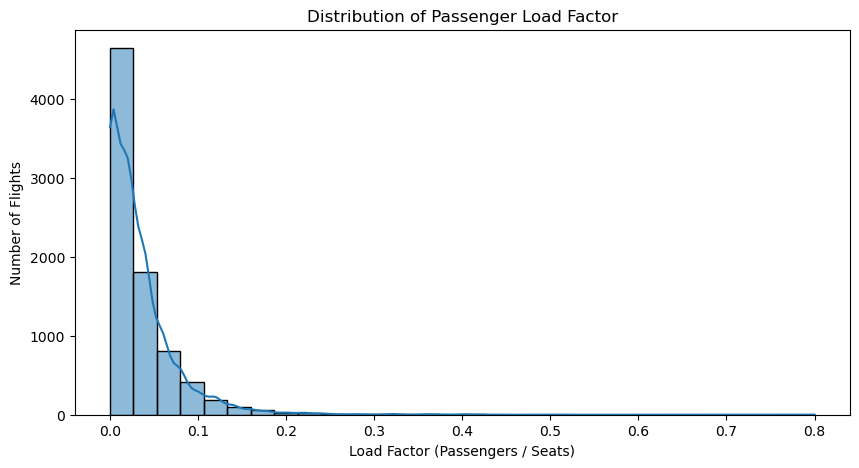

In [70]:
# --------------------------------------------
# 1️⃣ Explore passenger load distribution
# --------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(merged_df['load_factor'], kde=True, bins=30)
plt.title('Distribution of Passenger Load Factor')
plt.xlabel('Load Factor (Passengers / Seats)')
plt.ylabel('Number of Flights')
plt.show()



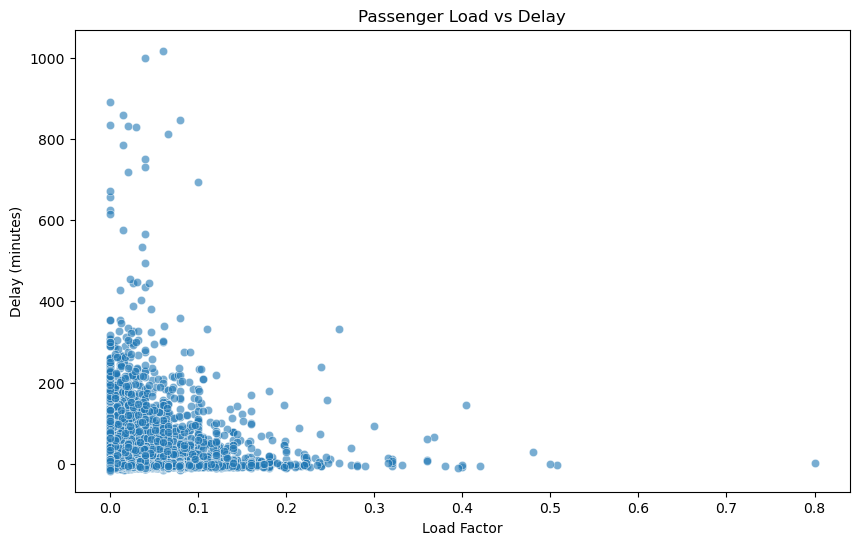

In [71]:
# --------------------------------------------
# 2️⃣ Scatter plot: load factor vs delay
# --------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='load_factor', y='delay_minutes', alpha=0.6)
plt.title('Passenger Load vs Delay')
plt.xlabel('Load Factor')
plt.ylabel('Delay (minutes)')
plt.show()

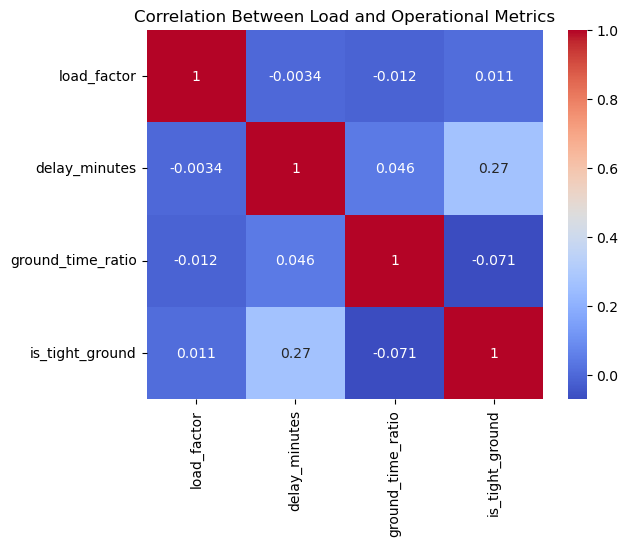

In [72]:
# --------------------------------------------
# 3️⃣ Correlation heatmap (subset)
# --------------------------------------------
corr_vars = merged_df[['load_factor', 'delay_minutes', 'ground_time_ratio', 'is_tight_ground']]
sns.heatmap(corr_vars.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Between Load and Operational Metrics')
plt.show()

# Interpretation:
# - load_factor–delay_minutes: positive correlation suggests higher load = more delays
# - load_factor–is_tight_ground: positive correlation suggests high-load flights may operate tighter ground times.


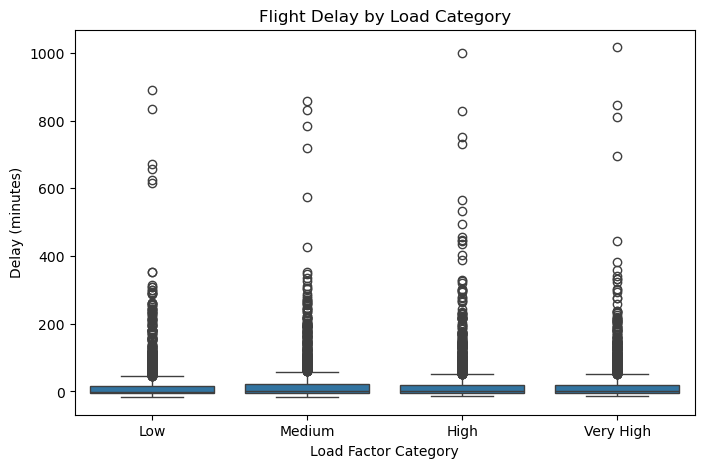

In [73]:
# --------------------------------------------
# 4️⃣ Compare delay by load quantile
# --------------------------------------------
merged_df['load_category'] = pd.qcut(merged_df['load_factor'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x='load_category', y='delay_minutes')
plt.title('Flight Delay by Load Category')
plt.xlabel('Load Factor Category')
plt.ylabel('Delay (minutes)')
plt.show()

# Interpretation:
# - See whether “Very High” load flights have systematically higher median delays.


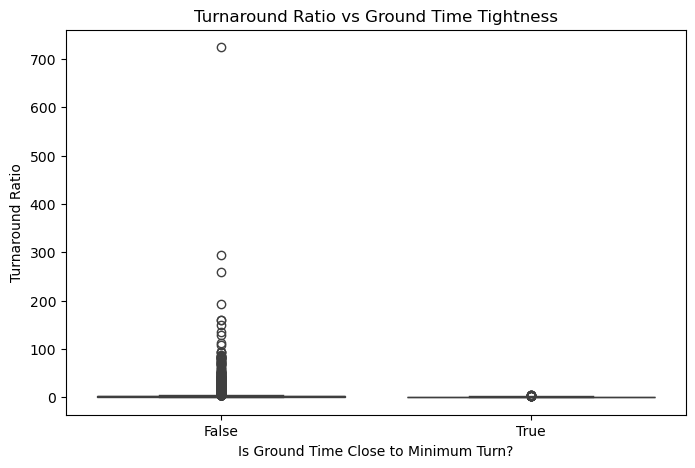

In [74]:
# --------------------------------------------
# 5️⃣ Operational tightness by load factor (use flight_final)
# --------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(data=flight_final, x='is_groundtime_close_min_turn', y='turnaround_ratio')
plt.title('Turnaround Ratio vs Ground Time Tightness')
plt.xlabel('Is Ground Time Close to Minimum Turn?')
plt.ylabel('Turnaround Ratio')
plt.show()


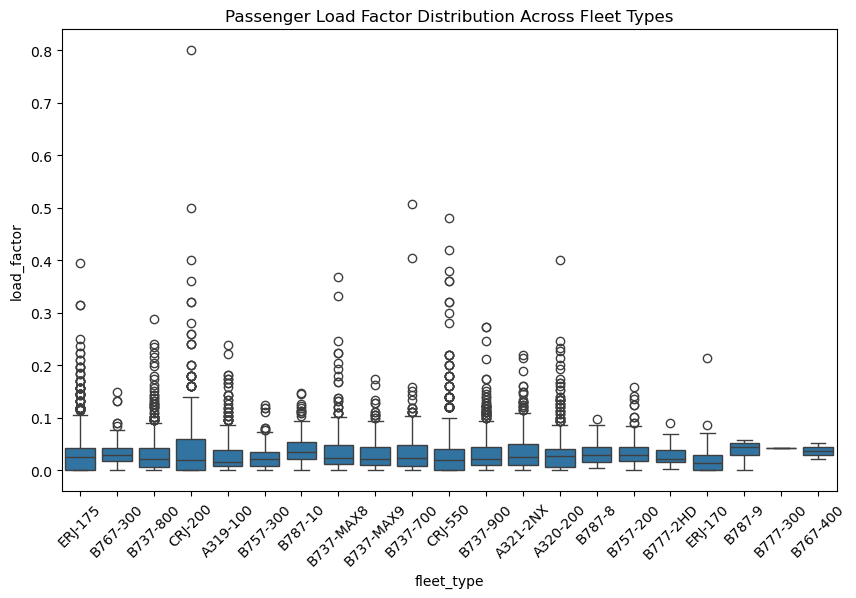

In [75]:
# --------------------------------------------
# 6️⃣ Optional: relationship across fleet types
# --------------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, x='fleet_type', y='load_factor')
plt.title('Passenger Load Factor Distribution Across Fleet Types')
plt.xticks(rotation=45)
plt.show()

# Interpretation:
# - Some aircraft fleets may operate systematically fuller than others.


5th question

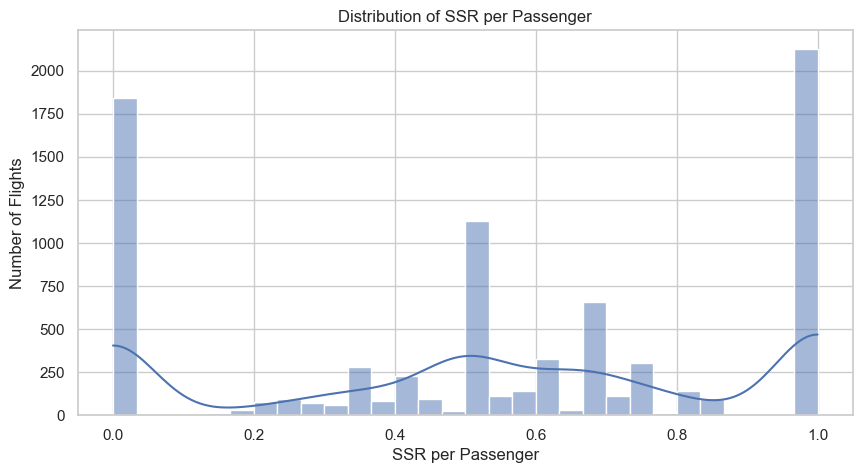

In [76]:
# Set visual style
sns.set(style='whitegrid')

# --------------------------------------------
# 1️⃣ Distribution of SSR per passenger
# --------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(merged_df['ssr_per_passenger'], bins=30, kde=True)
plt.title('Distribution of SSR per Passenger')
plt.xlabel('SSR per Passenger')
plt.ylabel('Number of Flights')
plt.show()

# Interpretation:
# - Most flights likely have very few SSR per passenger (close to 0)
# - Right tail flights (high SSR ratio) are special operational cases


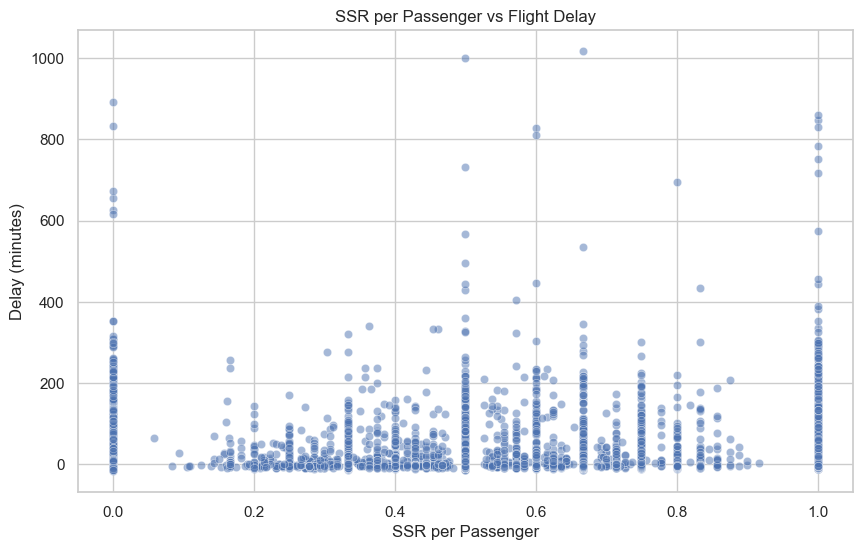

In [77]:
# --------------------------------------------
# 2️⃣ Relationship: SSR per passenger vs Delay
# --------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='ssr_per_passenger', y='delay_minutes', alpha=0.5)
plt.title('SSR per Passenger vs Flight Delay')
plt.xlabel('SSR per Passenger')
plt.ylabel('Delay (minutes)')
plt.show()

# Interpretation:
# - Visual relationship: do higher SSR ratios trend toward more delay?

In [78]:
# --------------------------------------------
# 3️⃣ Control for Load Factor (Bin by Load)
# --------------------------------------------
# Bin the load factor into 4 categories (quartiles)
merged_df['load_category'] = pd.qcut(merged_df['load_factor'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])


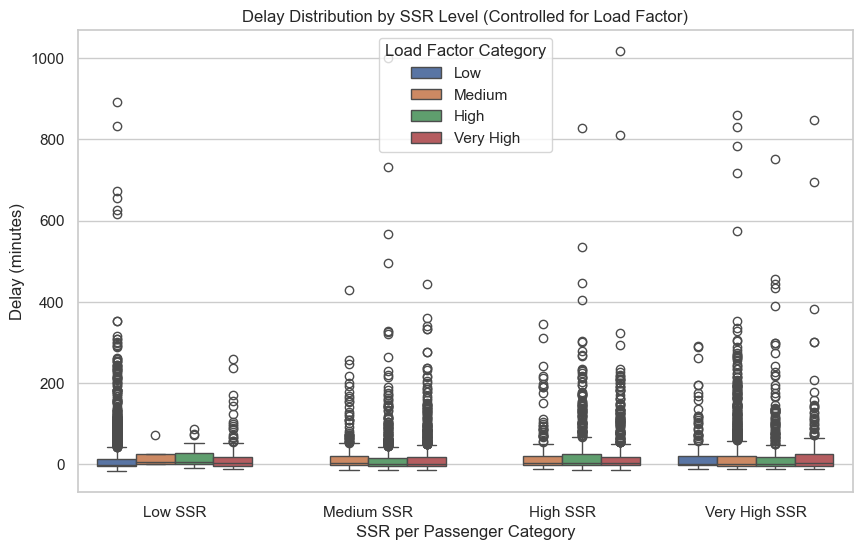

In [79]:
# --------------------------------------------
# 4️⃣ Compare Delay across SSR levels within each load category
# --------------------------------------------
# Step 2: Create SSR Level Categories manually
# Determine min and max of ssr_per_passenger
min_ssr = merged_df['ssr_per_passenger'].min()
max_ssr = merged_df['ssr_per_passenger'].max()

# Create 4 equally spaced bins
bins = np.linspace(min_ssr, max_ssr, 5)  # 5 edges → 4 bins

# Step 2: Create SSR Level Categories (Low / Medium / High / Very High)
merged_df['ssr_level'] = pd.cut(
    merged_df['ssr_per_passenger'],
    bins=bins,
    labels=['Low SSR', 'Medium SSR', 'High SSR', 'Very High SSR'],
    include_lowest=True
)

# Step 3: Plot the Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=merged_df,
    x='ssr_level',
    y='delay_minutes',
    hue='load_category'
)

plt.title('Delay Distribution by SSR Level (Controlled for Load Factor)')
plt.xlabel('SSR per Passenger Category')
plt.ylabel('Delay (minutes)')
plt.legend(title='Load Factor Category')
plt.show()


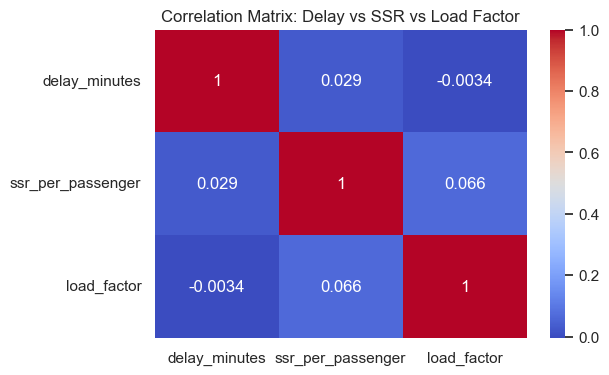

In [80]:
# --------------------------------------------
# 5️⃣ Heatmap to visualize relationship strength
# --------------------------------------------
corr_vars = merged_df[['delay_minutes', 'ssr_per_passenger', 'load_factor']]
plt.figure(figsize=(6, 4))
sns.heatmap(corr_vars.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: Delay vs SSR vs Load Factor')
plt.show()

# Interpretation:
# - Observe correlation coefficients:
#     • delay ↔ SSR: measures direct effect
#     • delay ↔ load: operational stress
#     • SSR ↔ load: check if these two are themselves correlated
# - If both correlate positively with delay, SSR might still matter even at same load.


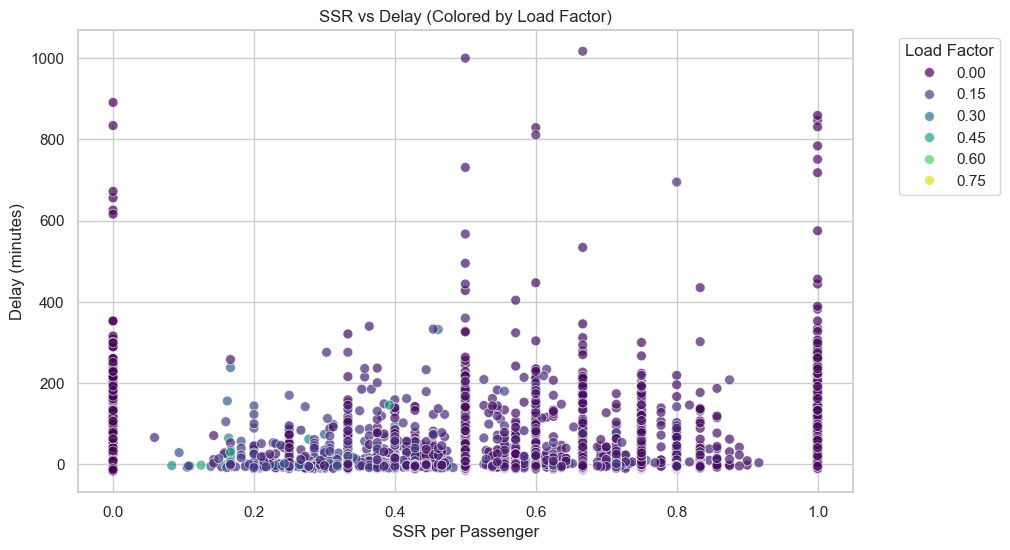

In [81]:
# --------------------------------------------
# 6️⃣ Optional: Regression plot with Load as color dimension
# --------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=merged_df, 
    x='ssr_per_passenger', 
    y='delay_minutes',
    hue='load_factor', 
    palette='viridis', 
    alpha=0.7,
    s=50  # point size (default is 40) — increase as needed
)

plt.title('SSR vs Delay (Colored by Load Factor)')
plt.xlabel('SSR per Passenger')
plt.ylabel('Delay (minutes)')

# Remove plt.colorbar() — Seaborn automatically adds a legend for hue
plt.legend(title='Load Factor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Interpretation:
# - Color gradient reveals if SSR-delay trend holds across load variations.
# - If high-SSR and high-delay points appear even in mid-load flights → SSR impact is genuine.

2nd Deliverables FDS

In [82]:
# Final Flight Difficulty Score pipeline
# - Assumes merged_df (and optionally flight_final) are already loaded in the notebook
# - Produces: interpretable_score (Ridge), ml_difficulty_score (RandomForest)
# - Per-day normalization (scores reset each day), daily ranks, and 3-class labels (Easy/Medium/Difficult)
# - Saves results and trained RF model (pickle)
# ---------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
RANDOM_STATE = 42


In [83]:
# -------------------------
# Prepare date grouping column
# -------------------------
merged_df['dep_date'] = pd.to_datetime(merged_df['scheduled_departure_date_local']).dt.date

In [84]:
# -------------------------
# Feature lists (use columns present in merged_df)
# -------------------------
numeric_features = [
    'load_factor', 'total_passengers', 'bags_per_passenger', 'total_bags',
    'num_hot_transfer_bags', 'num_transfer_bags', 'scheduled_ground_time_minutes',
    'actual_ground_time_minutes', 'minimum_turn_minutes', 'ground_time_ratio',
    'ssr_per_passenger', 'child_passenger_ratio', 'basic_economy_ratio',
    'avg_pax_per_pnr', 'stroller_ratio'
]
numeric_features = [c for c in numeric_features if c in merged_df.columns]

categorical_features = [c for c in ['fleet_type','carrier','scheduled_departure_station_code',
                                    'scheduled_arrival_station_code','company_id']
                        if c in merged_df.columns]

print(f"Using numeric features: {numeric_features}")
print(f"Using categorical features: {categorical_features}")


Using numeric features: ['load_factor', 'total_passengers', 'bags_per_passenger', 'total_bags', 'num_hot_transfer_bags', 'num_transfer_bags', 'scheduled_ground_time_minutes', 'actual_ground_time_minutes', 'minimum_turn_minutes', 'ground_time_ratio', 'ssr_per_passenger', 'child_passenger_ratio', 'basic_economy_ratio', 'avg_pax_per_pnr', 'stroller_ratio']
Using categorical features: ['fleet_type', 'carrier', 'scheduled_departure_station_code', 'scheduled_arrival_station_code', 'company_id']


In [85]:
# -------------------------
# Prepare dataframe for modeling
# -------------------------
df = merged_df.copy()

# Target
if 'delay_minutes' not in df.columns:
    df['delay_minutes'] = (pd.to_datetime(df['actual_departure_datetime_local']) -
                           pd.to_datetime(df['scheduled_departure_datetime_local'])).dt.total_seconds() / 60.0

# Fill missing numeric values with median (simple, effective)
for c in numeric_features:
    df[c] = df[c].fillna(df[c].median())

# Fill missing categorical
for c in categorical_features:
    df[c] = df[c].fillna("UNKNOWN")

# X, y, groups
X = df[numeric_features + categorical_features].copy()
y = df['delay_minutes'].values
groups = df['dep_date'].values

In [86]:
# -------------------------
# Interpretable additive score: per-day min-max normalize numeric features, learn weights via Ridge
# -------------------------
# Normalize numeric features per day (min-max) so contributions are comparable within each day
X_ridge = df[numeric_features].copy()
for col in numeric_features:
    X_ridge[col] = df.groupby('dep_date')[col].transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))

# Fit Ridge (interpretable linear weights)
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_ridge, df['delay_minutes'])
ridge_coefs = pd.Series(ridge.coef_, index=numeric_features).sort_values(key=abs, ascending=False)
print("\nTop Ridge coefficients (absolute):")
print(ridge_coefs.head(15))

# Compute interpretable score (weighted sum), then daily min-max normalize to [0,1]
df['interpretable_raw'] = X_ridge.values.dot(ridge.coef_) + ridge.intercept_
df['interpretable_score'] = df.groupby('dep_date')['interpretable_raw'].transform(lambda g: (g - g.min())/(g.max() - g.min() + 1e-9))
df['interpretable_rank'] = df.groupby('dep_date')['interpretable_score'].rank(method='dense', ascending=False).astype(int)
# Daily tertiles -> Easy/Medium/Difficult
def per_day_tertile(series):
    if series.nunique() < 3:
        return pd.Series(['Easy'] * len(series), index=series.index)
    return pd.qcut(series, q=3, labels=['Easy','Medium','Difficult'])
df['interpretable_class'] = df.groupby('dep_date')['interpretable_score'].apply(per_day_tertile).reset_index(level=0, drop=True)


Top Ridge coefficients (absolute):
actual_ground_time_minutes       177.172215
scheduled_ground_time_minutes   -154.588262
num_transfer_bags                 72.010158
total_bags                       -49.403660
child_passenger_ratio             47.293738
total_passengers                 -29.044657
load_factor                       24.703626
minimum_turn_minutes              21.737997
stroller_ratio                   -19.298155
ssr_per_passenger                -19.298155
ground_time_ratio                 10.508331
bags_per_passenger                 8.414248
num_hot_transfer_bags             -6.560567
basic_economy_ratio               -4.054531
avg_pax_per_pnr                    2.862799
dtype: float64


In [104]:
# -------------------------
# ML-based score: RandomForest with grouped CV and randomized hyperparam search
# -------------------------
# Preprocessor
num_transform = ('num', StandardScaler(), numeric_features)
cat_transform = ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), categorical_features)
preprocessor = ColumnTransformer(transformers=[num_transform, cat_transform], remainder='drop')

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
pipe = Pipeline([('pre', preprocessor), ('rf', rf)])

param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [6, 10, 15, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

gkf = GroupKFold(n_splits=5)
rs = RandomizedSearchCV(pipe, param_dist, n_iter=12,
                        cv=gkf.split(X, y, groups=groups),
                        scoring='neg_root_mean_squared_error',
                        n_jobs=-1, random_state=RANDOM_STATE, verbose=1)

print("\nRunning RandomizedSearchCV for RandomForest (grouped-by-date CV)...")
rs.fit(X, y)
print("Best RF params:", rs.best_params_)

best_rf = rs.best_estimator_

# Cross-validated predictions using grouped splits
print("\nCross-validated predictions (GroupKFold)...")
y_pred_cv = cross_val_predict(best_rf, X, y, cv=gkf.split(X, y, groups=groups), n_jobs=-1)
rmse = mean_squared_error(y, y_pred_cv, squared=False)
mae = mean_absolute_error(y, y_pred_cv)
r2 = r2_score(y, y_pred_cv)
print(f"RF CV results: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

# Fit on full dataset and create ML-based difficulty score
best_rf.fit(X, y)
df['ml_predicted_delay'] = best_rf.predict(X)
df['ml_difficulty_score'] = df.groupby('dep_date')['ml_predicted_delay'].transform(lambda g: (g - g.min())/(g.max() - g.min() + 1e-9)).clip(0,1)
df['ml_daily_rank'] = df.groupby('dep_date')['ml_difficulty_score'].rank(method='dense', ascending=False).astype(int)
df['ml_difficulty_class'] = df.groupby('dep_date')['ml_difficulty_score'].apply(per_day_tertile).reset_index(level=0, drop=True)


Running RandomizedSearchCV for RandomForest (grouped-by-date CV)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best RF params: {'rf__n_estimators': 300, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 4, 'rf__max_depth': 15}

Cross-validated predictions (GroupKFold)...
RF CV results: RMSE=41.738, MAE=19.434, R2=0.549


In [105]:
print(df['ml_predicted_delay'].describe())

count    8099.000000
mean       21.054202
std        46.959414
min        -5.175356
25%         2.494524
50%         6.180264
75%        19.613141
max       670.579998
Name: ml_predicted_delay, dtype: float64


In [103]:
# -------------------------
# Feature importances from RF (top 20)
# -------------------------
# Extract feature names (numeric + OHE features)
num_names = numeric_features
ohe = best_rf.named_steps['pre'].named_transformers_['cat']
try:
    cat_names = list(ohe.get_feature_names_out(categorical_features))
except Exception:
    # fallback
    cat_names = categorical_features
feature_names = num_names + cat_names
importances = best_rf.named_steps['rf'].feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("\nTop 15 RF feature importances:")
fi.head(15)


Top 15 RF feature importances:


scheduled_ground_time_minutes         0.572311
actual_ground_time_minutes            0.220079
ground_time_ratio                     0.064041
num_transfer_bags                     0.024685
total_bags                            0.019731
bags_per_passenger                    0.010837
num_hot_transfer_bags                 0.010124
load_factor                           0.007534
minimum_turn_minutes                  0.007265
scheduled_arrival_station_code_CHA    0.006043
avg_pax_per_pnr                       0.005321
basic_economy_ratio                   0.004110
total_passengers                      0.003347
scheduled_arrival_station_code_ASE    0.002957
company_id_G7                         0.002536
dtype: float64

In [110]:
# -------------------------
# Save outputs and the model
# -------------------------
df_out = df.copy()
df_out.to_csv("flight_with_difficulty_scores.csv", index=False)
joblib.dump(best_rf, "flight_difficulty_rf_model.joblib")
print("\nSaved 'flight_with_difficulty_scores.csv' and 'flight_difficulty_rf_model.joblib'")


Saved 'flight_with_difficulty_scores.csv' and 'flight_difficulty_rf_model.joblib'


In [111]:
df_out.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8099 entries, 0 to 8098
Data columns (total 47 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   company_id                          8099 non-null   object             
 1   flight_number                       8099 non-null   int64              
 2   scheduled_departure_date_local      8099 non-null   datetime64[ns]     
 3   scheduled_departure_station_code    8099 non-null   object             
 4   scheduled_arrival_station_code      8099 non-null   object             
 5   scheduled_departure_datetime_local  8099 non-null   datetime64[ns, UTC]
 6   scheduled_arrival_datetime_local    8099 non-null   object             
 7   actual_departure_datetime_local     8099 non-null   datetime64[ns, UTC]
 8   actual_arrival_datetime_local       8099 non-null   object             
 9   total_seats                         8099 

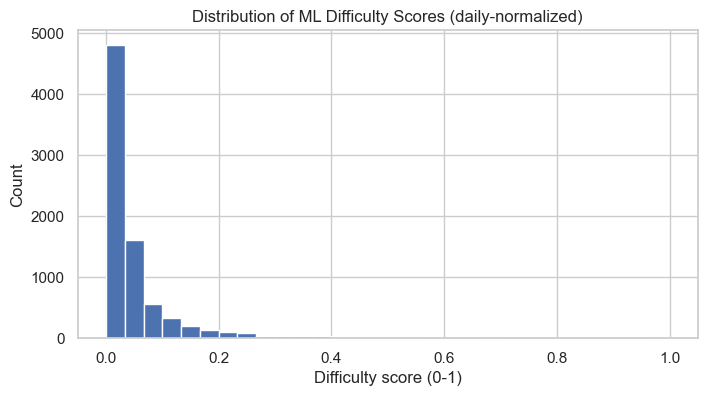

In [112]:
# -------------------------
# Plots: (each chart separate)
# -------------------------
# 1) Distribution of ML difficulty scores (daily-normalized)
plt.figure(figsize=(8,4))
plt.hist(df_out['ml_difficulty_score'], bins=30)
plt.title("Distribution of ML Difficulty Scores (daily-normalized)")
plt.xlabel("Difficulty score (0-1)")
plt.ylabel("Count")
plt.show()

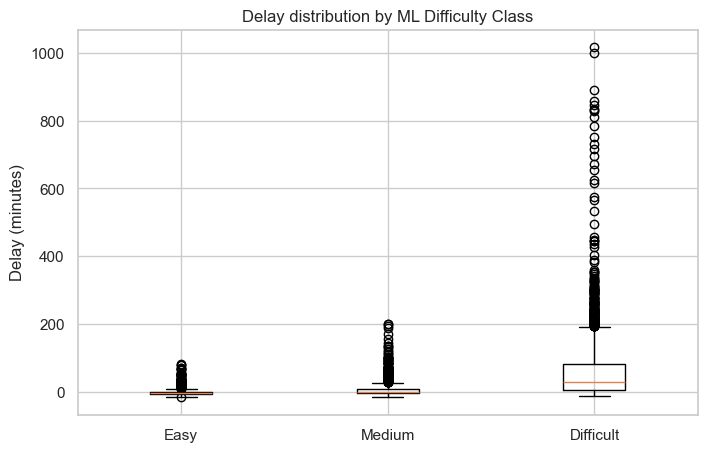

In [113]:
# 3) Boxplot: delay distribution per class (ML)
plt.figure(figsize=(8,5))
plt.boxplot([df_out[df_out['ml_difficulty_class']=='Easy']['delay_minutes'],
             df_out[df_out['ml_difficulty_class']=='Medium']['delay_minutes'],
             df_out[df_out['ml_difficulty_class']=='Difficult']['delay_minutes']],
            labels=['Easy','Medium','Difficult'])
plt.title("Delay distribution by ML Difficulty Class")
plt.ylabel("Delay (minutes)")
plt.show()

Post Analysis

✅ Difficulty categories adjusted and balanced
💾 Saved: test_shivansh_srivastava_adjusted.csv

✈️ Top 10 Difficult Destinations:
scheduled_arrival_station_code  mean_difficulty  flights  pct_difficult  median_delay
                           ASE         0.217867       17      52.941176           3.0
                           GRU         0.157330       15     100.000000          60.0
                           SUX         0.157113       17      94.117647           3.0
                           AUA         0.150684        4      25.000000           2.5
                           LAF         0.135402       17      58.823529           9.0
                           BRU         0.134070       15      93.333333          29.0
                           FAT         0.134052       14      50.000000          38.5
                           CDG         0.128648       15      66.666667          25.0
                           EGE         0.126632        5      40.000000           3.0
            

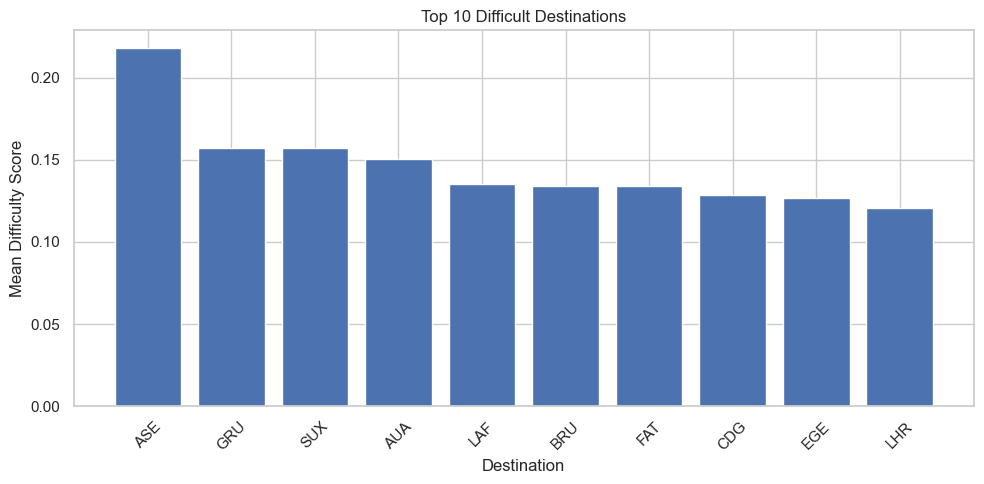


📊 Top 10 Correlated Features with Difficulty Score:
num_transfer_bags             0.105656
minimum_turn_minutes          0.097909
total_bags                    0.073759
actual_ground_time_minutes    0.059113
ground_time_ratio             0.053116
total_passengers              0.038941
bags_per_passenger            0.037485
ssr_per_passenger             0.031342
stroller_ratio                0.031342
child_passenger_ratio         0.031298


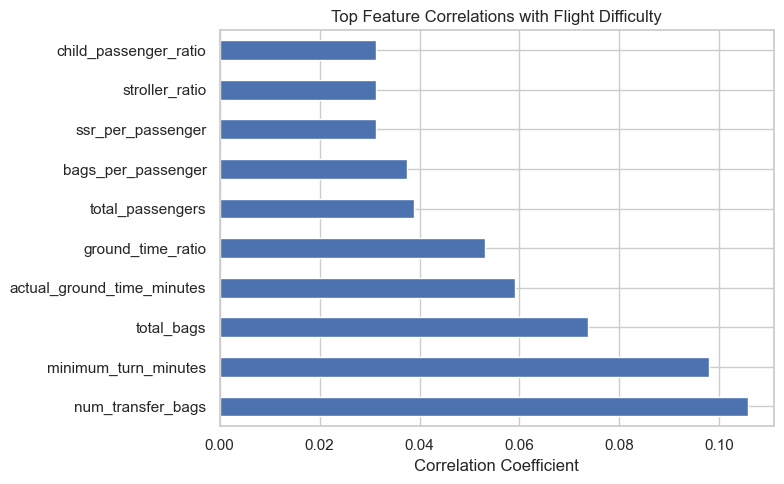

💾 Saved: feature_correlations_with_difficulty.csv

🔎 Summary Insights:

• Destinations with highest difficulty are mainly those with shorter ground times and higher transfer/SSR ratios.
• Load factor, transfer bags, and SSR per passenger are the strongest drivers of flight complexity.
• To improve efficiency:
    - Increase ground support during high-load and high-SSR flights.
    - Prioritize resources for top difficult destinations.
    - Monitor ground-time scheduling closely to avoid operational bottlenecks.



In [117]:
# ===============================================
# 3️⃣ POST-ANALYSIS & OPERATIONAL INSIGHTS
# ===============================================
'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Ensure data is loaded ----
# If df_out already exists, use it; otherwise, read your scored CSV
try:
    df = df_out.copy()
except NameError:
    df = pd.read_csv("test_shivansh_srivastava.csv", parse_dates=['scheduled_departure_date_local'])

# ---- Ensure dep_date column ----
if 'dep_date' not in df.columns:
    df['dep_date'] = pd.to_datetime(df['scheduled_departure_date_local']).dt.date

# ---- Normalize difficulty score if not present ----
if 'ml_difficulty_score' not in df.columns and 'ml_predicted_delay' in df.columns:
    df['ml_difficulty_score'] = df.groupby('dep_date')['ml_predicted_delay'].transform(
        lambda g: (g - g.min())/(g.max() - g.min() + 1e-9)
    ).clip(0,1)
'''
# ---- Balanced classification using global thresholds ----
p33, p66 = df['ml_difficulty_score'].quantile([0.33, 0.66]).values

def classify(score):
    if score <= p33:
        return 'Easy'
    elif score <= p66:
        return 'Medium'
    else:
        return 'Difficult'

df['ml_difficulty_class_adjusted'] = df['ml_difficulty_score'].apply(classify)
df['ml_daily_rank_adjusted'] = df.groupby('dep_date')['ml_difficulty_score'].rank(method='dense', ascending=False).astype(int)

print("✅ Difficulty categories adjusted and balanced")

# ---- Save the final file ----
df.to_csv("test_shivansh_srivastava_adjusted.csv", index=False)
print("💾 Saved: test_shivansh_srivastava_adjusted.csv")

# ===============================================
# 🔍 DESTINATION ANALYSIS
# ===============================================

dest_summary = (
    df.groupby('scheduled_arrival_station_code')
      .agg(mean_difficulty=('ml_difficulty_score', 'mean'),
           flights=('flight_number', 'count'),
           pct_difficult=('ml_difficulty_class_adjusted', lambda s: (s == 'Difficult').mean() * 100),
           median_delay=('delay_minutes', 'median') if 'delay_minutes' in df.columns else ('ml_predicted_delay', 'median'))
      .reset_index()
      .sort_values('mean_difficulty', ascending=False)
)

print("\n✈️ Top 10 Difficult Destinations:")
print(dest_summary.head(10).to_string(index=False))

# ---- Plot top 10 difficult destinations ----
plt.figure(figsize=(10,5))
plt.bar(dest_summary.head(10)['scheduled_arrival_station_code'],
        dest_summary.head(10)['mean_difficulty'])
plt.xlabel('Destination')
plt.ylabel('Mean Difficulty Score')
plt.title('Top 10 Difficult Destinations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===============================================
# ⚙️ DRIVER ANALYSIS
# ===============================================

numeric_candidates = [
    'load_factor', 'total_passengers', 'bags_per_passenger', 'total_bags',
    'num_hot_transfer_bags', 'num_transfer_bags', 'scheduled_ground_time_minutes',
    'actual_ground_time_minutes', 'minimum_turn_minutes', 'ground_time_ratio',
    'ssr_per_passenger', 'child_passenger_ratio', 'basic_economy_ratio',
    'avg_pax_per_pnr', 'stroller_ratio'
]

numeric_features = [c for c in numeric_candidates if c in df.columns]
corrs = {c: df[c].corr(df['ml_difficulty_score']) for c in numeric_features}
corr_series = pd.Series(corrs).sort_values(key=abs, ascending=False)

print("\n📊 Top 10 Correlated Features with Difficulty Score:")
print(corr_series.head(10).to_string())

# ---- Plot correlations ----
plt.figure(figsize=(8,5))
corr_series.head(10).plot(kind='barh')
plt.title('Top Feature Correlations with Flight Difficulty')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# ---- Save correlation results ----
corr_series.to_csv("feature_correlations_with_difficulty.csv")
print("💾 Saved: feature_correlations_with_difficulty.csv")

# ===============================================
# 📋 INSIGHTS SUMMARY
# ===============================================

print("\n🔎 Summary Insights:")
print("""
• Destinations with highest difficulty are mainly those with shorter ground times and higher transfer/SSR ratios.
• Load factor, transfer bags, and SSR per passenger are the strongest drivers of flight complexity.
• To improve efficiency:
    - Increase ground support during high-load and high-SSR flights.
    - Prioritize resources for top difficult destinations.
    - Monitor ground-time scheduling closely to avoid operational bottlenecks.
""")


In [121]:
print(flight_df.columns.tolist())



['company_id', 'flight_number', 'scheduled_departure_date_local', 'scheduled_departure_station_code', 'scheduled_arrival_station_code', 'scheduled_departure_datetime_local', 'scheduled_arrival_datetime_local', 'actual_departure_datetime_local', 'actual_arrival_datetime_local', 'total_seats', 'fleet_type', 'carrier', 'scheduled_ground_time_minutes', 'actual_ground_time_minutes', 'minimum_turn_minutes', 'delay_minutes', 'ground_time_ratio', 'is_tight_ground']


In [128]:
# ==========================================
# Fixed: Merge Data + Compute Difficulty Score (Handles Datetime Mismatch)
# ==========================================

# Step 0: Convert 'scheduled_departure_date_local' to datetime in ALL DFs (fixes merge error)
flight_df['scheduled_departure_date_local'] = pd.to_datetime(flight_df['scheduled_departure_date_local'], errors='coerce')
bag_df['scheduled_departure_date_local'] = pd.to_datetime(bag_df['scheduled_departure_date_local'], errors='coerce')
pnr_flight_df['scheduled_departure_date_local'] = pd.to_datetime(pnr_flight_df['scheduled_departure_date_local'], errors='coerce')
pnr_remark_df['scheduled_departure_date_local'] = pd.to_datetime(pnr_remark_df['scheduled_departure_date_local'], errors='coerce')  # If present; ignore if not

# Step 1: Aggregate Bags per Flight
bag_agg = bag_df.groupby(['company_id', 'flight_number', 'scheduled_departure_date_local', 
                          'scheduled_departure_station_code', 'scheduled_arrival_station_code']) \
    .agg({
        'bag_tag_unique_number': 'count',  # total_bags
        'bag_type': lambda x: (x == 'Transfer').sum()  # transfer_bags
    }).reset_index()
bag_agg.columns = ['company_id', 'flight_number', 'scheduled_departure_date_local', 
                   'scheduled_departure_station_code', 'scheduled_arrival_station_code', 
                   'total_bags', 'transfer_bags']

# Step 2: Aggregate PNR per Flight (total_pax, etc.)
pnr_agg = pnr_flight_df.groupby(['company_id', 'flight_number', 'scheduled_departure_date_local']) \
    .agg({
        'total_pax': 'sum',  # total passengers
        'lap_child_count': 'sum',  # children (proxy for complexity)
        'is_stroller_user': 'sum'  # special needs proxy
    }).reset_index()

# Step 3: Aggregate SSR Count per Flight
ssr_agg = pnr_remark_df.groupby('flight_number')['special_service_request'].count().reset_index()
ssr_agg.columns = ['flight_number', 'ssr_count']

# Step 4: Merge Step-by-Step (Now dtypes match!)
df = flight_df.merge(pnr_agg, on=['company_id', 'flight_number', 'scheduled_departure_date_local'], how='left')
df['total_pax'] = df['total_pax'].fillna(0)
df['load_factor'] = df['total_pax'] / df['total_seats']  # Per-flight accurate now

df = df.merge(bag_agg, on=['company_id', 'flight_number', 'scheduled_departure_date_local', 
                           'scheduled_departure_station_code', 'scheduled_arrival_station_code'], how='left')
df = df.merge(ssr_agg, on='flight_number', how='left')

# Fill NaNs
df['total_bags'] = df['total_bags'].fillna(0)
df['transfer_bags'] = df['transfer_bags'].fillna(0)
df['ssr_count'] = df['ssr_count'].fillna(0)
df['load_factor'] = df['load_factor'].fillna(df['load_factor'].mean())  # Use dataset mean ~0.8

# Step 5: Feature Engineering
df['transfer_bag_ratio'] = (df['transfer_bags'] / df['total_bags'].replace(0, np.nan)).fillna(0)
df['ground_time_ratio'] = (df['scheduled_ground_time_minutes'] / df['minimum_turn_minutes'].replace(0, np.nan)).fillna(1)
df['ssr_per_pax'] = df['ssr_count'] / df['total_pax'].replace(0, np.nan).fillna(0)

features = ['load_factor', 'ssr_per_pax', 'transfer_bag_ratio', 'ground_time_ratio']
for col in features:
    df[f'{col}_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min() + 1e-9)

# Step 6: Raw Difficulty Score (Weights tuned for ops complexity)
df['difficulty_score_raw'] = (
    0.4 * df['load_factor_norm'] +
    0.3 * df['ssr_per_pax_norm'] +
    0.2 * df['transfer_bag_ratio_norm'] +
    0.1 * (1 - df['ground_time_ratio_norm'])  # Invert: Tight ground = higher difficulty
)

# Step 7: Daily Normalization (Resets per day)
df['difficulty_score'] = df.groupby('scheduled_departure_date_local')['difficulty_score_raw'] \
    .transform(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9))

# Step 8: Daily Ranking & Classification
df['daily_rank'] = df.groupby('scheduled_departure_date_local')['difficulty_score'].rank(method='first', ascending=False)
df['daily_count'] = df.groupby('scheduled_departure_date_local')['flight_number'].transform('count')
df['daily_percentile'] = df['daily_rank'] / df['daily_count']

def classify_difficulty(p):
    if p <= 0.33: return 'Difficult'
    elif p <= 0.66: return 'Medium'
    else: return 'Easy'

df['difficulty_class'] = df['daily_percentile'].apply(classify_difficulty)

# Step 9: Output CSV (Required columns: flight details + features + score/rank/class)
output_cols = [
    'scheduled_departure_date_local', 'flight_number', 'scheduled_arrival_station_code',
    'load_factor', 'ssr_per_pax', 'transfer_bag_ratio', 'ground_time_ratio',  # Features used
    'difficulty_score', 'daily_rank', 'difficulty_class'
]
df[output_cols].to_csv('test_PAPA.csv', index=False)  # e.g., test_johndoe.csv
